#**Project-1: Impact of community-based incentive on maternal health**

#**1. Data Cleaning and Transformation**

**Note: Please change the current path and input the path to your specific google drive folder where the relevant datasets for project-1 are located before running the code.**

In [ ]:
# Import the 'drive' module from the 'google.colab' package to enable Google Drive integration.
# Then, mount Google Drive to the '/drive' directory within the Colab environment.
# The 'force_remount=True' parameter ensures that the Drive is remounted even if it was previously mounted.
from google.colab import drive
drive.mount('/drive', force_remount=True)
# Change the current working directory to the specified folder within Google Drive,
# where you can save and load your Colab notebooks or files.
%cd '/drive/MyDrive/CapstoneProjectCode'

Mounted at /drive
/drive/MyDrive/CapstoneProjectCode


In [ ]:
import pandas as pd
import numpy as np

# Upload and load the NHC-level data
nhc_df = pd.read_csv('project1_nhc_level.csv')
nhc_df.head()

,facilitytype,fid,month,treatment,pair,referred,accompanied,total,pop_total,training,femalenhc_ratio,femalesmag_ratio
0,Rural Health Centre,91,1,0,29,3.0,0.0,3.0,647.0,0,0.375000,0.4
1,Rural Health Centre,91,1,0,29,13.0,0.0,13.0,2096.0,0,0.428571,0.6
2,Rural Health Centre,91,1,0,29,1.0,0.0,1.0,694.0,0,0.444444,0.4
3,Rural Health Centre,91,1,0,29,4.0,0.0,4.0,714.0,0,0.571429,0.6
4,Rural Health Centre,91,1,0,29,7.0,0.0,7.0,1276.0,0,0.500000,0.4


In [ ]:
fac_df = pd.read_csv('project1_facility_level.csv')
fac_df.head()

,no_maternity_beds,distance_dmo,pop_catchment,anc_first_tri_num,pair,treatment,fid,yr_month,institutionaldeliveries,institutionaldeliverycoverage,...,pair_43,pair_44,pair_45,pair_46,pair_47,pair_48,pair_49,post,d,facilitytype
0,1,95.0,7751,50,42,0,3,201801,2.0,55.0,...,0,0,0,0,0,0,0,0.0,Chibombo,Rural Health Centre
1,1,95.0,7751,50,42,0,3,201802,13.0,43.4,...,0,0,0,0,0,0,0,0.0,Chibombo,Rural Health Centre
2,1,95.0,7751,50,42,0,3,201803,19.0,51.9,...,0,0,0,0,0,0,0,0.0,Chibombo,Rural Health Centre
3,1,95.0,7751,50,42,0,3,201804,24.0,76.6,...,0,0,0,0,0,0,0,0.0,Chibombo,Rural Health Centre
4,1,95.0,7751,50,42,0,3,201805,25.0,77.3,...,0,0,0,0,0,0,0,0.0,Chibombo,Rural Health Centre


Independent Variables:
From NHC data: treatment, femalenhc_ratio, femalesmag_ratio, pop_total

From Facility-level data: facilitytype, pop_catchment, no_maternity_beds, distance_dmo

Dependent Variables:

From NHC data: referred, accompanied, total

From Facility-level data: institutionaldeliveries, institutionaldeliverycoverage, stanccoverage1sttrimester, anc_first_tri_num

In [ ]:
# Selecting independent and dependent variables from the NHC-level data
nhc_columns = ['treatment', 'femalenhc_ratio', 'femalesmag_ratio', 'pop_total',
               'referred', 'accompanied', 'total', 'facilitytype', 'pair', 'month','fid']
nhc_subset = nhc_df[nhc_columns]

# Selecting independent and dependent variables from the Facility-level data
fac_columns = ['treatment', 'facilitytype', 'pop_catchment', 'no_maternity_beds',
               'distance_dmo', 'institutionaldeliveries', 'institutionaldeliverycoverage',
               'stanccoverage1sttrimester', 'anc_first_tri_num', 'pair', 'yr_month','fid','d']
fac_subset = fac_df[fac_columns]

print("NHC-level subset:")
print(nhc_subset.head())

print("Facility-level subset:")
print(fac_subset.head())

NHC-level subset:
   treatment  femalenhc_ratio  femalesmag_ratio  pop_total  referred  \
0          0         0.375000               0.4      647.0       3.0   
1          0         0.428571               0.6     2096.0      13.0   
2          0         0.444444               0.4      694.0       1.0   
3          0         0.571429               0.6      714.0       4.0   
4          0         0.500000               0.4     1276.0       7.0   

   accompanied  total         facilitytype  pair  month  fid  
0          0.0    3.0  Rural Health Centre    29      1   91  
1          0.0   13.0  Rural Health Centre    29      1   91  
2          0.0    1.0  Rural Health Centre    29      1   91  
3          0.0    4.0  Rural Health Centre    29      1   91  
4          0.0    7.0  Rural Health Centre    29      1   91  
Facility-level subset:
   treatment         facilitytype  pop_catchment  no_maternity_beds  \
0          0  Rural Health Centre           7751                  1   
1     

In [ ]:
# Check missing values in both datasets
print("Missing values in NHC data:")
print(nhc_subset.isnull().sum())

print("\nMissing values in Facility data:")
print(fac_subset.isnull().sum())

Missing values in NHC data:
treatment              0
femalenhc_ratio     1122
femalesmag_ratio    1284
pop_total           1068
referred            1320
accompanied         1322
total               1311
facilitytype           0
pair                   0
month                  0
fid                    0
dtype: int64

Missing values in Facility data:
treatment                          0
facilitytype                       0
pop_catchment                      0
no_maternity_beds                  0
distance_dmo                       0
institutionaldeliveries          306
institutionaldeliverycoverage      0
stanccoverage1sttrimester          0
anc_first_tri_num                  0
pair                               0
yr_month                           0
fid                                0
d                                  0
dtype: int64


In [ ]:
# Drop rows with missing values if they are minimal:
nhc_clean = nhc_subset.dropna()
fac_clean = fac_subset.dropna()
print(nhc_clean.isnull().sum())
print(fac_clean.isnull().sum())

treatment           0
femalenhc_ratio     0
femalesmag_ratio    0
pop_total           0
referred            0
accompanied         0
total               0
facilitytype        0
pair                0
month               0
fid                 0
dtype: int64
treatment                        0
facilitytype                     0
pop_catchment                    0
no_maternity_beds                0
distance_dmo                     0
institutionaldeliveries          0
institutionaldeliverycoverage    0
stanccoverage1sttrimester        0
anc_first_tri_num                0
pair                             0
yr_month                         0
fid                              0
d                                0
dtype: int64


In [ ]:
# Columns chosen to be converted to categorical from both datasets: Treatment, fid, pair, facility type, training
# Convert some columns to categorical in nhc data
nhc_clean['treatment'] = nhc_clean['treatment'].astype('category')
nhc_clean['fid'] = nhc_clean['fid'].astype('category')
nhc_clean['pair'] = nhc_clean['fid'].astype('category')
nhc_clean['facilitytype'] = nhc_clean['facilitytype'].astype('category')
nhc_df['training'] = nhc_df['training'].astype('category')


# Convert some columns to categorical in fac data
fac_clean['treatment'] = fac_clean['treatment'].astype('category')
fac_clean['fid'] = fac_clean['fid'].astype('category')
fac_clean['facilitytype'] = fac_clean['facilitytype'].astype('category')


nhc_clean.info()
fac_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2892 entries, 0 to 4996
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   treatment         2892 non-null   category
 1   femalenhc_ratio   2892 non-null   float64 
 2   femalesmag_ratio  2892 non-null   float64 
 3   pop_total         2892 non-null   float64 
 4   referred          2892 non-null   float64 
 5   accompanied       2892 non-null   float64 
 6   total             2892 non-null   float64 
 7   facilitytype      2892 non-null   category
 8   pair              2892 non-null   category
 9   month             2892 non-null   int64   
 10  fid               2892 non-null   category
dtypes: category(4), float64(6), int64(1)
memory usage: 197.8 KB
<class 'pandas.core.frame.DataFrame'>
Index: 2515 entries, 0 to 2820
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         ----------

<ipython-input-7-0dd38a689c34>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nhc_clean['treatment'] = nhc_clean['treatment'].astype('category')
<ipython-input-7-0dd38a689c34>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nhc_clean['fid'] = nhc_clean['fid'].astype('category')
<ipython-input-7-0dd38a689c34>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

In [ ]:
# Need to drop every year before 2020 for the FAC dataset
fac_clean_2020 = fac_clean[(fac_clean['yr_month'] >= 202001) & (fac_clean['yr_month'] <= 202006)]
fac_clean_2020.head()

,treatment,facilitytype,pop_catchment,no_maternity_beds,distance_dmo,institutionaldeliveries,institutionaldeliverycoverage,stanccoverage1sttrimester,anc_first_tri_num,pair,yr_month,fid,d
24,0,Rural Health Centre,7751,1,95.0,10.0,53.7,4.4,50,42,202001,3,Chibombo
25,0,Rural Health Centre,7751,1,95.0,5.0,44.7,6.3,50,42,202002,3,Chibombo
26,0,Rural Health Centre,7751,1,95.0,8.0,25.4,13.3,50,42,202003,3,Chibombo
27,0,Rural Health Centre,7751,1,95.0,4.0,26.2,7.6,50,42,202004,3,Chibombo
28,0,Rural Health Centre,7751,1,95.0,10.0,55.2,10.3,50,42,202005,3,Chibombo


**Reasoning for filtering based on the 2020 year & months 1-6:** <br>
The study explicitly states that the monetary incentives were assigned to community-based volunteers in treatment sites, and payments were made for every woman referred or accompanied in the first trimester of pregnancy for the period January 2020 to June 2020.

In [ ]:
fac_clean = fac_clean.copy()
nhc_clean = nhc_clean.copy()

# Create an empty list to store the months
month_list = []

# Go through each value in the 'yr_month' column
for value in fac_clean['yr_month']:

  # Convert the value to a string, like '201801'
  value_str = str(value)

  # Get the last two characters (the month part)
  month_str = value_str[-2:]

  # Convert the month string to an integer, like '01' → 1
  month_int = int(month_str)

  # Add the result to our list
  month_list.append(month_int)

# Add the list as a new column in the dataframe
fac_clean.loc[:, 'month'] = month_list

# Make sure NHC dataframe have 'month' column as integers
nhc_clean['month'] = nhc_clean['month'].astype(int)

In [ ]:
#Merge nhc and fac on fid & month
merged_df = pd.merge(nhc_clean, fac_clean, on=['fid', 'month'], suffixes=('_nhc', '_fac'))

# Check the merged DataFrame
print("Merged data preview")
print(merged_df.head())
null_counts = merged_df.isnull().sum()
print(null_counts)

Merged data preview
  treatment_nhc  femalenhc_ratio  femalesmag_ratio  pop_total  referred  \
0             0         0.375000               0.4      647.0       3.0   
1             0         0.375000               0.4      647.0       3.0   
2             0         0.375000               0.4      647.0       3.0   
3             0         0.428571               0.6     2096.0      13.0   
4             0         0.428571               0.6     2096.0      13.0   

   accompanied  total     facilitytype_nhc pair_nhc  month  ...  \
0          0.0    3.0  Rural Health Centre       91      1  ...   
1          0.0    3.0  Rural Health Centre       91      1  ...   
2          0.0    3.0  Rural Health Centre       91      1  ...   
3          0.0   13.0  Rural Health Centre       91      1  ...   
4          0.0   13.0  Rural Health Centre       91      1  ...   

   pop_catchment no_maternity_beds distance_dmo  institutionaldeliveries  \
0          14237                 3         45.0   

#**2. Parallel Design RCT**

In [ ]:
# A table view of the merged dataset
merged_df.head()

,treatment_nhc,femalenhc_ratio,femalesmag_ratio,pop_total,referred,accompanied,total,facilitytype_nhc,pair_nhc,month,...,pop_catchment,no_maternity_beds,distance_dmo,institutionaldeliveries,institutionaldeliverycoverage,stanccoverage1sttrimester,anc_first_tri_num,pair_fac,yr_month,d
0,0,0.375000,0.4,647.0,3.0,0.0,3.0,Rural Health Centre,91,1,...,14237,3,45.0,35.0,70.5,63.9,444,29,201801,Serenje
1,0,0.375000,0.4,647.0,3.0,0.0,3.0,Rural Health Centre,91,1,...,14237,3,45.0,38.0,42.6,57.8,444,29,201901,Serenje
2,0,0.375000,0.4,647.0,3.0,0.0,3.0,Rural Health Centre,91,1,...,14237,3,45.0,45.0,86.2,87.2,444,29,202001,Serenje
3,0,0.428571,0.6,2096.0,13.0,0.0,13.0,Rural Health Centre,91,1,...,14237,3,45.0,35.0,70.5,63.9,444,29,201801,Serenje
4,0,0.428571,0.6,2096.0,13.0,0.0,13.0,Rural Health Centre,91,1,...,14237,3,45.0,38.0,42.6,57.8,444,29,201901,Serenje


In [ ]:
# Counts the # of rows for the merged dataframe
n_rows = len(merged_df)
# Print the number of rows
print('The number of rows in merged_df:',n_rows)

The number of rows in merged_df: 7224


#**<mark>Section 2.1: Hypothesis #1 Description NHC-Level</mark>** <br>
  | H0: The intervention/treatment (incentives for CBVs) will lead to an increase in the total number of women referred and accompanied by CBVs(Community-Based Volunteers). <br>
  | HA: The intervention/treatment (incentives for CBVs) will NOT lead to an increase total number of women referred and accompanied by CBVs(Community-Based Volunteers). <br>

Notes From Report 1: The incentive/treatment was monetary aid given to NHCs() for either referring or escorting women to seek ANC(Antenatal Care) within the first trimester(14 weeks). In the control health facilities, the status quo is maintained where CBVs support health service delivery on a voluntary basis with no monetary benefits. In the treatment health facilities,the CBVs are provided with monetary incentives.<br>

**Variables Used for Parallel Design Hypothesis 1:** <br>

Independent Variables: treatment_nhc <br>
  - This variable indicates whether the facility received an intervention involving monetary incentives for the CBVs (treatment group) or not (control group). <br>
  - 1 represents the treatment group (i.e., facilities where Community-Based Volunteers (CBVs) receive incentives).
  - 0 represents the control group (i.e., facilities where CBVs do not receive incentives, and they continue to work on a voluntary basis).

Dependent Variable: total <br>
  - This represents the total number of women who were referred and accompanied by CBVs to seek ANC during the first trimester. <br>

**<mark>Section 2.2: Power Analysis, Sample Size, & Associated Graph</mark>** </br>
>Effect Size: Medium (0.5)</br>
Power: 0.85 <br>
Total Sample Size: 146 </br>

In [ ]:
from statsmodels.stats.power import TTestIndPower

# Power Analysis for Parallel Design Scenario

# Medium effect size
effect_size = 0.5
# Significance level
alpha = 0.05
# Power value
power = 0.85
# parallel design
number_groups = 2

# Current dataset size: total rows in your dataset
dataset_size = len(merged_df)
current_sample_size = dataset_size

# Creating a power analysis object
analysis = TTestIndPower()

# Calculating the required sample size per group
result = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)

# Rounding to get integer sample size
required_sample_size_per_group = round(result)

# Total sample size required for the experiment
total_sample_size = required_sample_size_per_group * number_groups

# Output the result
print(f'Required sample size per group: {required_sample_size_per_group}')
print(f'Total sample size for all groups: {total_sample_size}')

Required sample size per group: 73
Total sample size for all groups: 146


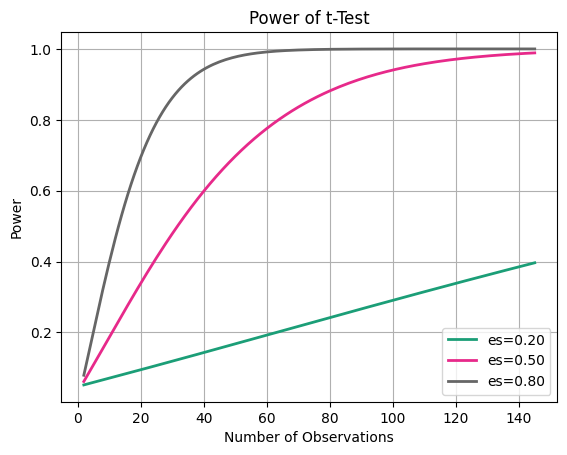

In [ ]:
from numpy import array
from matplotlib import pyplot

# Effect sizes: small (0.2), medium (0.5), large (0.8)
effect_sizes = array([0.2, 0.5, 0.8])

# Sample sizes: range from 2 to 146
sample_sizes = array(range(2, 146))

# Create a power analysis object for t-tests
analysis = TTestIndPower()

# Plot power curves
analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes, alpha=0.05, title='Power of t-Test')

# Formatting the plot
pyplot.grid()
pyplot.ylabel('Power')
pyplot.show()

**<mark>Section 2.3: Initial Parallel Design Setup For Hypothesis 1</mark>** <br>

  1. Creating the required subset for parallel design on hypothesis 1. Participants are randomly assigned to either the treatment or control group. They remain in their assigned group throughout the study.To achieve medium effect, a total of 146 participants are selected from dataset. <br>

  2. Splitting the participants into either treatment or control. Random participants will be selected from the original dataset such that: <br>
    - Group 1 (Treatment - Incentives, 73 participants)
    - Group 2 (Control - No Incentives, 73 participants)


In [ ]:
import numpy as np
import pandas as pd

# Setting the seed for reproducibility
np.random.seed(42)

# Subset and label groups
parallel1_subset_df = merged_df[["treatment_nhc", "total", "fid", "month"]].copy()

# Create a new column 'Group_Label' in the dataframe based on the 'treatment_nhc' column
# If 'treatment_nhc' is 1, assign 'Treatment'; if 'treatment_nhc' is 0, assign 'Control'

# Initialize an empty list to store the new labels
group_labels = []

# Loop through each row in the 'treatment_nhc' column
for index, row in parallel1_subset_df.iterrows():
  # Check the value in the 'treatment_nhc' column
  if row['treatment_nhc'] == 1:
    # If it's 1, append 'Treatment'
    group_labels.append('Treatment')
  else:
    # If it's 0, append 'Control'
    group_labels.append('Control')

# Add the list of labels as a new column in the dataframe
parallel1_subset_df['Group_Label'] = group_labels


# Split into Treatment and Control groups
treatment_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Treatment']
control_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Control']

# Randomly sample 73 from the split dataset for each of the group type
sample_treatment = treatment_df.sample(n=73, random_state=42, replace=True)
sample_control = control_df.sample(n=73, random_state=42, replace=True)

# Combine both samples
selected_participants = pd.concat([sample_treatment, sample_control], ignore_index=True)

# Checking to see if there are equal number of participants in both groups
print(selected_participants['Group_Label'].value_counts())

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Displaying the selected subset of features and participants
selected_participants.head()

Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

----------------------------------------------------------------------



,treatment_nhc,total,fid,month,Group_Label
0,1,14.0,118,6,Treatment
1,1,0.0,18,6,Treatment
2,1,1.0,115,2,Treatment
3,1,1.0,122,3,Treatment
4,1,1.0,18,2,Treatment


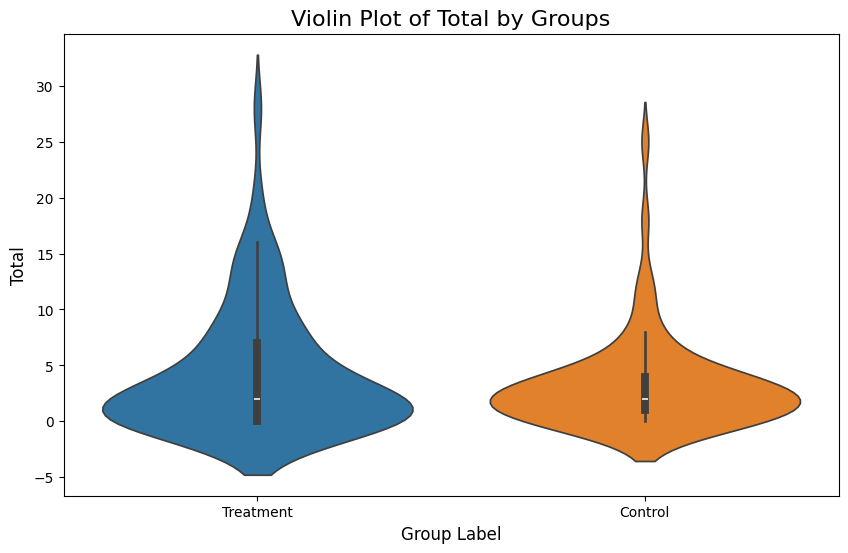

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the violin plot for Treatment and Control groups (using your 'Treatment' column)
plt.figure(figsize=(10, 6))
sns.violinplot(x="Group_Label", y="total", data=selected_participants, hue="Group_Label",
               order=["Treatment", "Control"], legend=False)

# Adding the titles and labels to the plot
plt.title('Violin Plot of Total by Groups', fontsize=16)
plt.xlabel('Group Label', fontsize=12)
plt.ylabel('Total', fontsize=12)

# Displaying the plot
plt.show()

**<mark>Section 2.4: Parallel Design Setup With Blocking Factor For Hypothesis 1</mark>** <br>

Blocking Factor: facilitytype_nhc

Reason: The outcome variable (i.e. total referrals/accompanied number) could be dependent on the type of facility that the womens are being placed in. We want to account for the variability within different types of facilities.

In [ ]:
# Get the unique levels for the blocking factor 'facilitytype_nhc'
blocking_factor_levels = merged_df['facilitytype_nhc'].unique()
print(blocking_factor_levels)

['Rural Health Centre', 'Health Post - Rural']
Categories (2, object): ['Health Post - Rural', 'Rural Health Centre']


In [ ]:
import numpy as np
import pandas as pd

# Setting the seed for reproducibility
np.random.seed(42)

# Subset and label groups
parallel1_subset_df = merged_df[["treatment_nhc", "total", "fid", "month", "facilitytype_nhc"]].copy()

# Create a new column 'Group_Label' in the dataframe based on the 'treatment_nhc' column
# If 'treatment_nhc' is 1, assign 'Treatment'; if 'treatment_nhc' is 0, assign 'Control'

# Initialize an empty list to store the new labels
group_labels = []

# Loop through each row in the 'treatment_nhc' column
for index, row in parallel1_subset_df.iterrows():
  # Check the value in the 'treatment_nhc' column
  if row['treatment_nhc'] == 1:
    # If it's 1, append 'Treatment'
    group_labels.append('Treatment')
  else:
    # If it's 0, append 'Control'
    group_labels.append('Control')

# Add the list of labels as a new column in the dataframe
parallel1_subset_df['Group_Label'] = group_labels

# Split the dataset by the blocking factor: Facility Type
facility1 = parallel1_subset_df[parallel1_subset_df['facilitytype_nhc'] == 'Rural Health Centre']
facility2 = parallel1_subset_df[parallel1_subset_df['facilitytype_nhc'] == 'Health Post - Rural']

# Sample 37 from each facility type for both Treatment and Control
sample_facility1_treatment = facility1[facility1['Group_Label'] == 'Treatment'].sample(n=37, random_state=42, replace=True)
sample_facility2_treatment = facility2[facility2['Group_Label'] == 'Treatment'].sample(n=37, random_state=42, replace=True)
sample_facility1_control   = facility1[facility1['Group_Label'] == 'Control'].sample(n=37, random_state=42, replace=True)
sample_facility2_control   = facility2[facility2['Group_Label'] == 'Control'].sample(n=37, random_state=42, replace=True)

# Combine all sampled data: here we have more samples than required (148) so we will randomly drop two to meet the 146 requirement
selected_participants_block = pd.concat([sample_facility1_treatment, sample_facility1_control,sample_facility2_treatment, sample_facility2_control], ignore_index=True)

# Now from the combined dataset drop randomly a treatment and control row each
drop_treatment_idx = selected_participants_block[selected_participants_block['Group_Label'] == 'Treatment'].sample(n=1, random_state=42).index
drop_control_idx   = selected_participants_block[selected_participants_block['Group_Label'] == 'Control'].sample(n=1, random_state=42).index
# Drop the selected rows, now each group will contain 73 participants again
selected_participants_block.drop(index=drop_treatment_idx, inplace=True)
selected_participants_block.drop(index=drop_control_idx, inplace=True)

# Checking to see if there are equal number of participants in both groups
print(selected_participants_block['Group_Label'].value_counts())

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Displaying the selected subset of features and participants
selected_participants_block.head()

Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

----------------------------------------------------------------------



,treatment_nhc,total,fid,month,facilitytype_nhc,Group_Label
0,1,11.0,30,2,Rural Health Centre,Treatment
1,1,6.0,26,3,Rural Health Centre,Treatment
2,1,0.0,55,3,Rural Health Centre,Treatment
3,1,0.0,62,3,Rural Health Centre,Treatment
5,1,3.0,24,5,Rural Health Centre,Treatment


>**Checking for Normality of Dependent Variable: Total**

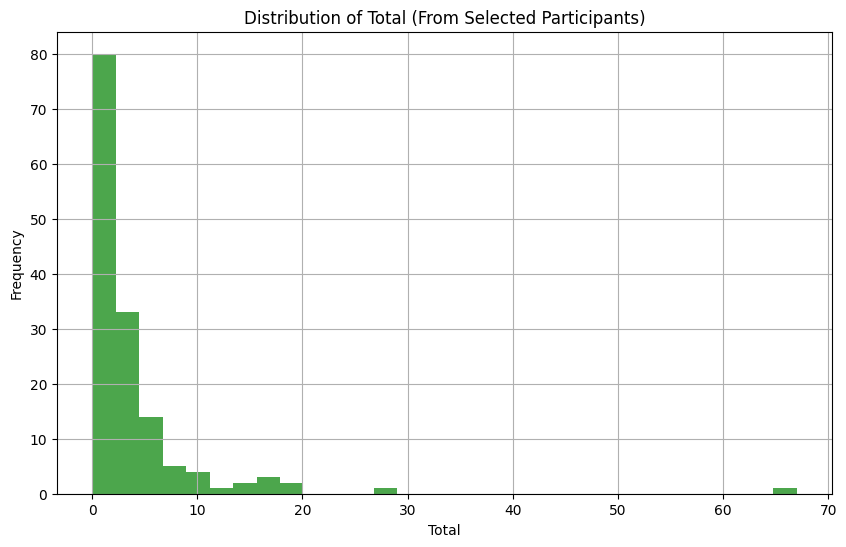

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram of the 'total' values in the selected sample
plt.figure(figsize=(10, 6))
plt.hist(selected_participants_block['total'].dropna(), bins=30, color='green', alpha=0.7)

# Add title and axis labels
plt.title('Distribution of Total (From Selected Participants)')
plt.xlabel('Total')
plt.ylabel('Frequency')

# Add a grid for readability
plt.grid(True)

# Show the plot
plt.show()

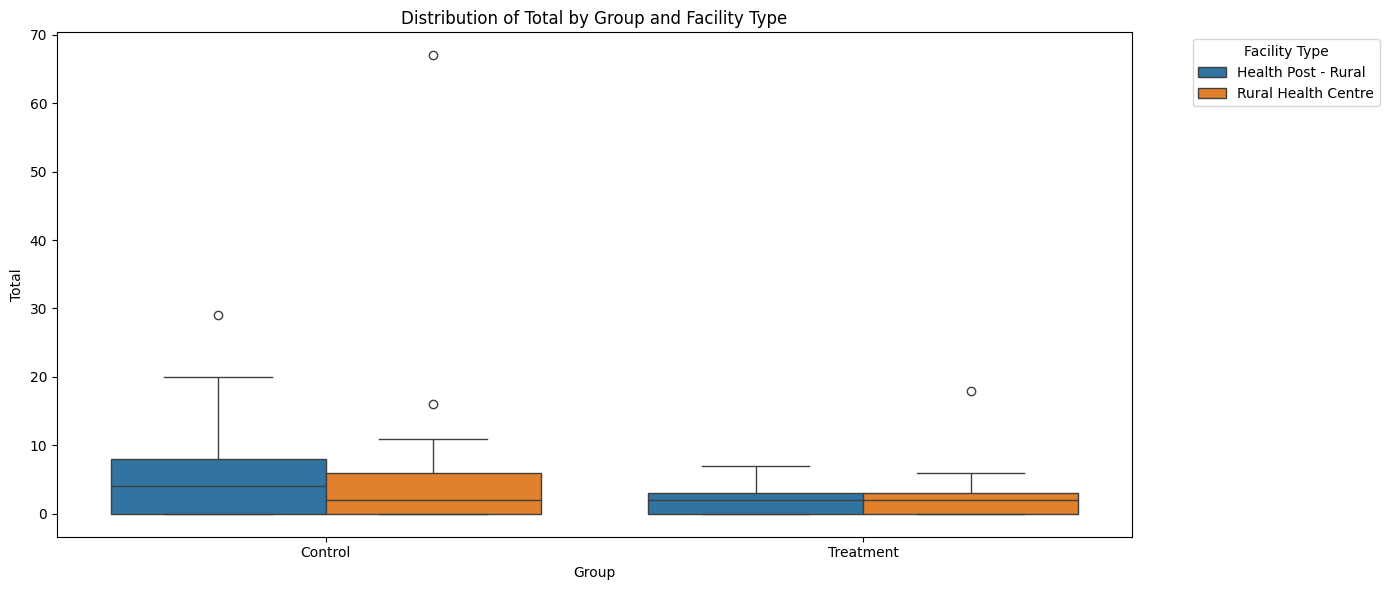

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values if any (optional safety step)
cleaned_df = selected_participants_block.dropna(subset=['total', 'Group_Label', 'facilitytype_nhc'])

# Create the boxplot
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=cleaned_df, x="Group_Label", y="total", hue="facilitytype_nhc")

# Customize x-axis tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Treatment'], rotation=0)

# Customize the plot (labels, title, etc.)
ax.set_title('Distribution of Total by Group and Facility Type')
ax.set_xlabel('Group')
ax.set_ylabel('Total')

# Add legend
plt.legend(title='Facility Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show plot
plt.show()

>**TWO-WAY ANOVA & SUMMARY STATISTICS BEOFRE LOG-TRANSFORMATION: After blocking using facility type level and then randomly assigning each participant into two groups (i.e. treatment/control) we use two-way ANOVA to find the significance of the blocking factor based on the p-value**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Example formula using variables from your dataset
formula = 'total ~ Group_Label + facilitytype_nhc + Group_Label:facilitytype_nhc'

# Fit the model
model = ols(formula, data=selected_participants_block).fit()

# Perform ANOVA and print table
aov_table = sm.stats.anova_lm(model)
print(aov_table)

# Print the model summary
print(model.summary())

                                 df       sum_sq     mean_sq         F  \
Group_Label                     1.0   346.746575  346.746575  7.469057   
facilitytype_nhc                1.0     0.383238    0.383238  0.008255   
Group_Label:facilitytype_nhc    1.0    13.213259   13.213259  0.284619   
Residual                      142.0  6592.266517   46.424412       NaN   

                                PR(>F)  
Group_Label                   0.007075  
facilitytype_nhc              0.927734  
Group_Label:facilitytype_nhc  0.594524  
Residual                           NaN  
                            OLS Regression Results                            
Dep. Variable:                  total   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     2.587
Date:                Mon, 14 Apr 2025   Prob (F-statistic):             0.0554
Time:                        

**TUKEY'S HSD TEST: Post-hoc analysis following Two-Way ANOVA Before Log-Transformation**

> SOURCE: https://campus.datacamp.com/courses/experimental-design-in-python/analyzing-experimental-data-statistical-tests-and-power?ex=5

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey's HSD test for Group_Label
tukey_group = pairwise_tukeyhsd(endog=selected_participants_block['total'], groups=selected_participants['Group_Label'], alpha=0.05)

print("\nTukey HSD Test Results for Group_Label (Treatment vs Control):")
print(tukey_group)


Tukey HSD Test Results for Group_Label (Treatment vs Control):
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj   lower  upper  reject
-------------------------------------------------------
Control Treatment   0.2329 0.8398 -2.0401 2.5059  False
-------------------------------------------------------


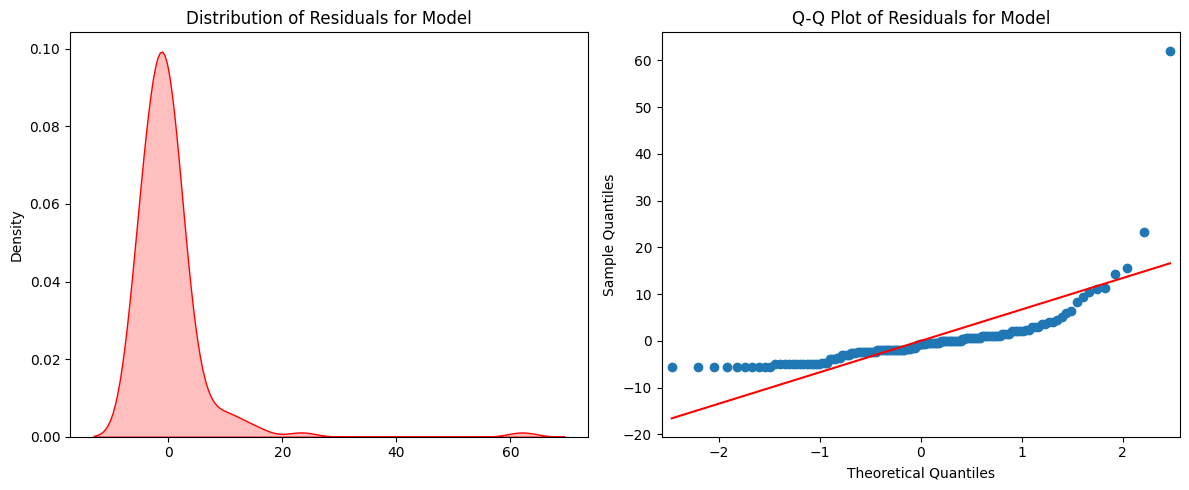

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get residuals after fitting the model
residuals = model.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residuals, ax=ax[0], color='red', fill=True)
ax[0].set_title('Distribution of Residuals for Model')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals for Model')

# Plotting the graphs
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Perform Shapiro-Wilk test on residuals
shapiro_res = stats.shapiro(residuals.dropna())

print(f'W: {round(shapiro_res[0], 3)}, P-value: {round(shapiro_res[1], 3)}')

W: 0.545, P-value: 0.0


> **<mark>The dependent variable (i.e. total) doesn't follow normal distribution, hence, we must log transform it. Everything below this uses the log-transformed total**

In [ ]:
selected_participants_block['log_total'] = np.log(selected_participants_block['total'] + 1)
selected_participants_block.head()

,treatment_nhc,total,fid,month,facilitytype_nhc,Group_Label,log_total
0,1,11.0,30,2,Rural Health Centre,Treatment,2.484907
1,1,6.0,26,3,Rural Health Centre,Treatment,1.945910
2,1,0.0,55,3,Rural Health Centre,Treatment,0.000000
3,1,0.0,62,3,Rural Health Centre,Treatment,0.000000
5,1,3.0,24,5,Rural Health Centre,Treatment,1.386294


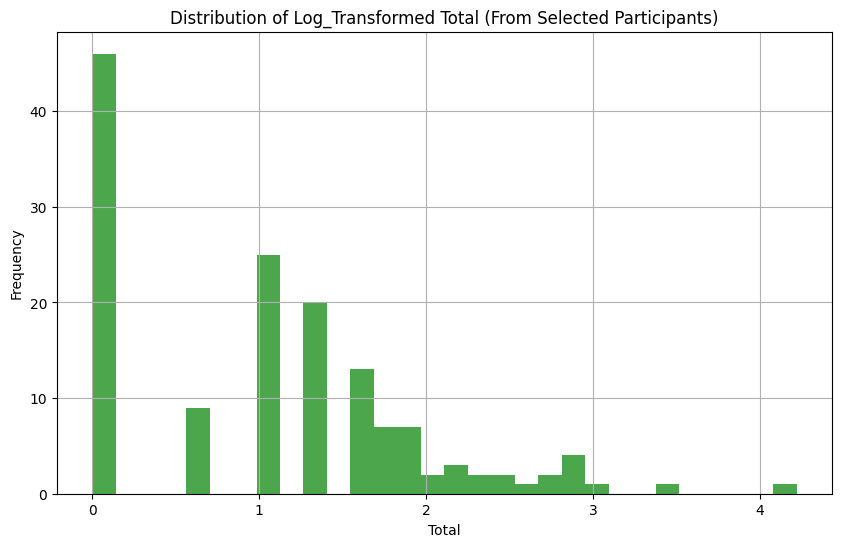

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram of the 'total' values in the selected sample
plt.figure(figsize=(10, 6))
plt.hist(selected_participants_block['log_total'].dropna(), bins=30, color='green', alpha=0.7)

# Add title and axis labels
plt.title('Distribution of Log_Transformed Total (From Selected Participants)')
plt.xlabel('Total')
plt.ylabel('Frequency')

# Add a grid for readability
plt.grid(True)

# Show the plot
plt.show()

>**Violin Plot to Display the Distribution after the Blocking & Randomization for Parallel Design**

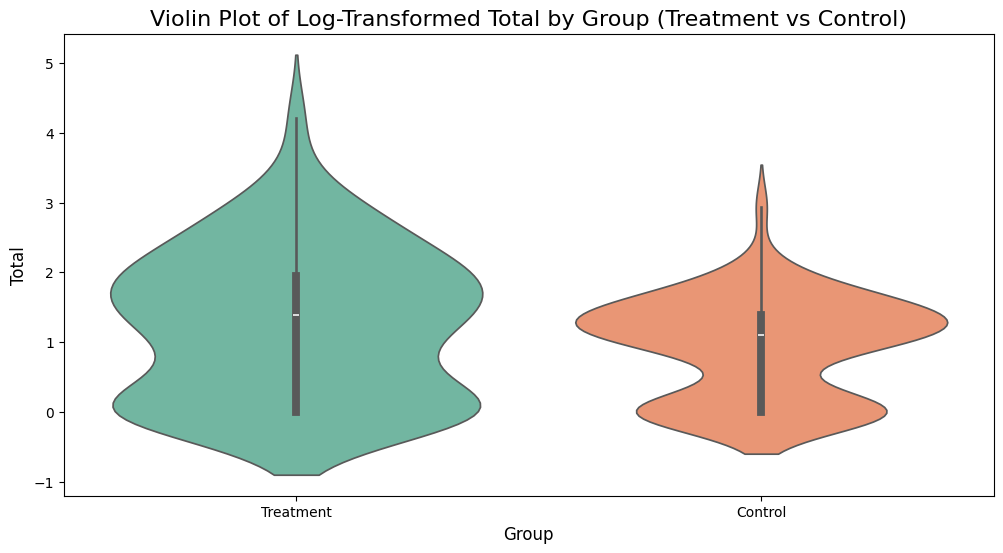

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Group_Label", y="log_total", data=selected_participants_block, hue="Group_Label",
               order=["Treatment", "Control"], palette="Set2")

# Add title and labels
plt.title('Violin Plot of Log-Transformed Total by Group (Treatment vs Control)', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Total', fontsize=12)

# Show the plot
plt.show()

>**Boxplot: A more clear visualization of the distribution after separating into different Facility levels and Incentive types (i.e. treatment/control groups)**

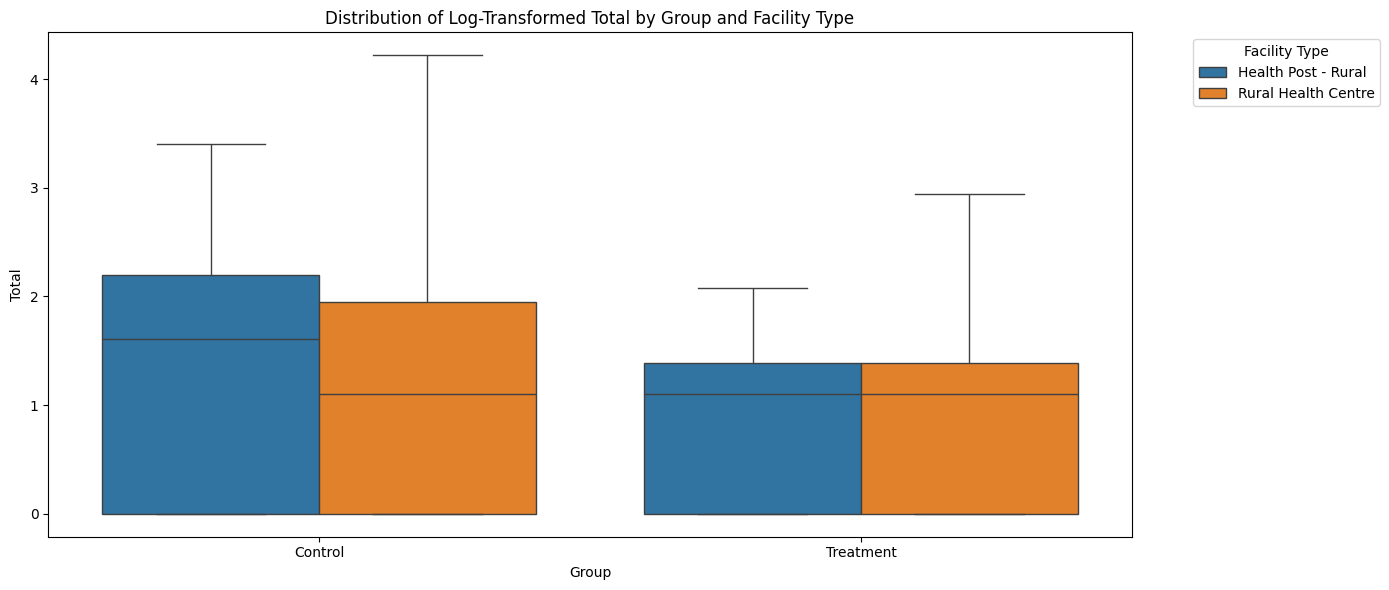

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values if any (optional safety step)
cleaned_df = selected_participants_block.dropna(subset=['log_total', 'Group_Label', 'facilitytype_nhc'])

# Create the boxplot
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=cleaned_df, x="Group_Label", y="log_total", hue="facilitytype_nhc")

# Customize x-axis tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Treatment'], rotation=0)

# Customize the plot (labels, title, etc.)
ax.set_title('Distribution of Log-Transformed Total by Group and Facility Type')
ax.set_xlabel('Group')
ax.set_ylabel('Total')

# Add legend
plt.legend(title='Facility Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show plot
plt.show()

>**TWO-WAY ANOVA & SUMMARY STATISTICS AFTER LOG_TRANSFORMATION: After blocking using facility type level and then randomly assigning each participant into two groups (i.e. treatment/control) we use two-way ANOVA to find the significance of the blocking factor based on the p-value**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Example formula using variables from your dataset
formula1 = 'log_total ~ Group_Label + facilitytype_nhc + Group_Label:facilitytype_nhc'

# Fit the model
model1 = ols(formula1, data=selected_participants_block).fit()

# Perform ANOVA and print table
aov_table = sm.stats.anova_lm(model1)
print(aov_table)

# Print the model summary
print(model1.summary())

                                 df      sum_sq   mean_sq         F    PR(>F)
Group_Label                     1.0    3.780810  3.780810  4.624341  0.033215
facilitytype_nhc                1.0    0.291422  0.291422  0.356441  0.551440
Group_Label:facilitytype_nhc    1.0    1.311634  1.311634  1.604271  0.207373
Residual                      142.0  116.097615  0.817589       NaN       NaN
                            OLS Regression Results                            
Dep. Variable:              log_total   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.195
Date:                Mon, 14 Apr 2025   Prob (F-statistic):             0.0913
Time:                        23:20:03   Log-Likelihood:                -190.44
No. Observations:                 146   AIC:                             388.9
Df Residuals:                     142   BIC:             

**TUKEY'S HSD TEST: Post-hoc analysis following Two-Way ANOVA**

> SOURCE: https://campus.datacamp.com/courses/experimental-design-in-python/analyzing-experimental-data-statistical-tests-and-power?ex=5

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey's HSD test for Group_Label
tukey_group = pairwise_tukeyhsd(endog=selected_participants_block['log_total'], groups=selected_participants['Group_Label'], alpha=0.05)

print("\nTukey HSD Test Results for Group_Label (Treatment vs Control):")
print(tukey_group)


Tukey HSD Test Results for Group_Label (Treatment vs Control):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower  upper  reject
------------------------------------------------------
Control Treatment  -0.0416 0.7849 -0.342 0.2589  False
------------------------------------------------------


**Checking Assumptions for Two-Way ANOVA:**

> 1. IID: Independently & Identically distributed taken care of by random sampling.
2. Normality: Testing for normality of residuals after fitting the model using the Shapiro-Wilk test
3. Homoscedasticity: variances of the dependent variable should be approximately equal across the different groups using

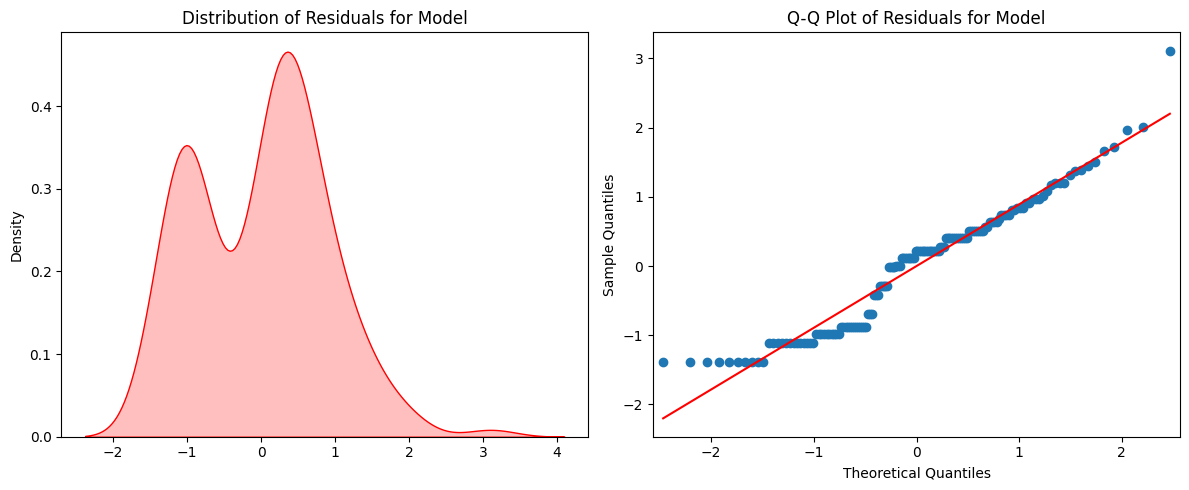

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get residuals after fitting the model
residuals1 = model1.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residuals1, ax=ax[0], color='red', fill=True)
ax[0].set_title('Distribution of Residuals for Model')

# Q-Q plot
sm.qqplot(residuals1, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals for Model')

# Plotting the graphs
plt.tight_layout()
plt.show()

>**Performing Shapiro-Wilk test on residuals after fitting the model to check for assumption of normality.**

In [ ]:
from scipy import stats

# Perform Shapiro-Wilk test on residuals
shapiro_res = stats.shapiro(residuals1.dropna())

print(f'W: {round(shapiro_res[0], 3)}, P-value: {round(shapiro_res[1], 3)}')

W: 0.948, P-value: 0.0


**<mark>Section 2.5: Parallel Design Setup With Continuous Covariates (exluding blocking factor) For Hypothesis 1</mark>** <br>
> **Covariate Used:** `femalehc_ratio` </br>

> **Subset Requirement:** We add the new continuous covariate variable into our subset but use the parallel design from the original setup.

> **GLM Requirements:** We removed `facilitytype_nhc` (used previously as a blocking factor) to isolate the effect of these numeric covariates in a GLM framework. The chosen covariate account for variability in referral behavior due to population size and gender dynamics in the NHC workforce. It is expected to influence how the incentives help increase total number of referrals/accompaniments.

In [ ]:
import numpy as np
import pandas as pd

# Setting the seed for reproducibility
np.random.seed(42)

# Subset and label groups
parallel1_subset_df = merged_df[["treatment_nhc", "total", "fid", "month", "femalenhc_ratio"]].copy()

# Create a new column 'Group_Label' in the dataframe based on the 'treatment_nhc' column
# If 'treatment_nhc' is 1, assign 'Treatment'; if 'treatment_nhc' is 0, assign 'Control'

# Initialize an empty list to store the new labels
group_labels = []

# Loop through each row in the 'treatment_nhc' column
for index, row in parallel1_subset_df.iterrows():
  # Check the value in the 'treatment_nhc' column
  if row['treatment_nhc'] == 1:
    # If it's 1, append 'Treatment'
    group_labels.append('Treatment')
  else:
    # If it's 0, append 'Control'
    group_labels.append('Control')

# Add the list of labels as a new column in the dataframe
parallel1_subset_df['Group_Label'] = group_labels


# Split into Treatment and Control groups
treatment_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Treatment']
control_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Control']

# Randomly sample 73 from the split dataset for each of the group type
sample_treatment = treatment_df.sample(n=73, random_state=42, replace=True)
sample_control = control_df.sample(n=73, random_state=42, replace=True)

# Combine both samples
selected_participants1_cov = pd.concat([sample_treatment, sample_control], ignore_index=True)

# Checking to see if there are equal number of participants in both groups
print(selected_participants1_cov['Group_Label'].value_counts())

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Displaying the selected subset of features and participants
selected_participants1_cov.head()

Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

----------------------------------------------------------------------



,treatment_nhc,total,fid,month,femalenhc_ratio,Group_Label
0,1,14.0,118,6,0.600000,Treatment
1,1,0.0,18,6,0.266667,Treatment
2,1,1.0,115,2,0.666667,Treatment
3,1,1.0,122,3,0.400000,Treatment
4,1,1.0,18,2,0.500000,Treatment


**Log transformation of dependent variable in an attempt to fix the normality assumption**

In [ ]:
selected_participants1_cov['log_total'] = np.log(selected_participants1_cov['total'] + 1)
selected_participants1_cov.head()

,treatment_nhc,total,fid,month,femalenhc_ratio,Group_Label,log_total
0,1,14.0,118,6,0.600000,Treatment,2.708050
1,1,0.0,18,6,0.266667,Treatment,0.000000
2,1,1.0,115,2,0.666667,Treatment,0.693147
3,1,1.0,122,3,0.400000,Treatment,0.693147
4,1,1.0,18,2,0.500000,Treatment,0.693147


>**SOURCE FOR ANCOVA CODE:** https://www.reneshbedre.com/blog/ancova.html

Note: This is using the dependent variable without log transformation.

In [ ]:
# Run ANCOVA with covariates (no blocking factor)
formula1_cov = 'Q("total") ~ C(treatment_nhc) + femalenhc_ratio + C(treatment_nhc):femalenhc_ratio'

# Fit the model using Ordinary Least Squares (OLS)
model1_cov = sm.formula.ols(formula1_cov, data = selected_participants1_cov).fit()

anova_cov1 = sm.stats.anova_lm(model1_cov, typ=2)
# Perform the Type III ANOVA and display the results
# Use typ=3 for Type III SS: used in ANCOVA because it tests the main effects and interactions, adjusting for the presence of other factors
aov_table = sm.stats.anova_lm(model1_cov, typ=3)
print(aov_table)
print(model1_cov.summary())

                                       sum_sq     df         F    PR(>F)
Intercept                           50.462475    1.0  2.051973  0.154207
C(treatment_nhc)                    26.667274    1.0  1.084381  0.299489
femalenhc_ratio                      0.443276    1.0  0.018025  0.893389
C(treatment_nhc):femalenhc_ratio    14.983565    1.0  0.609282  0.436358
Residual                          3492.088009  142.0       NaN       NaN
                            OLS Regression Results                            
Dep. Variable:             Q("total")   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.166
Date:                Mon, 14 Apr 2025   Prob (F-statistic):              0.325
Time:                        23:20:04   Log-Likelihood:                -438.91
No. Observations:                 146   AIC:                             885.8
Df Residu

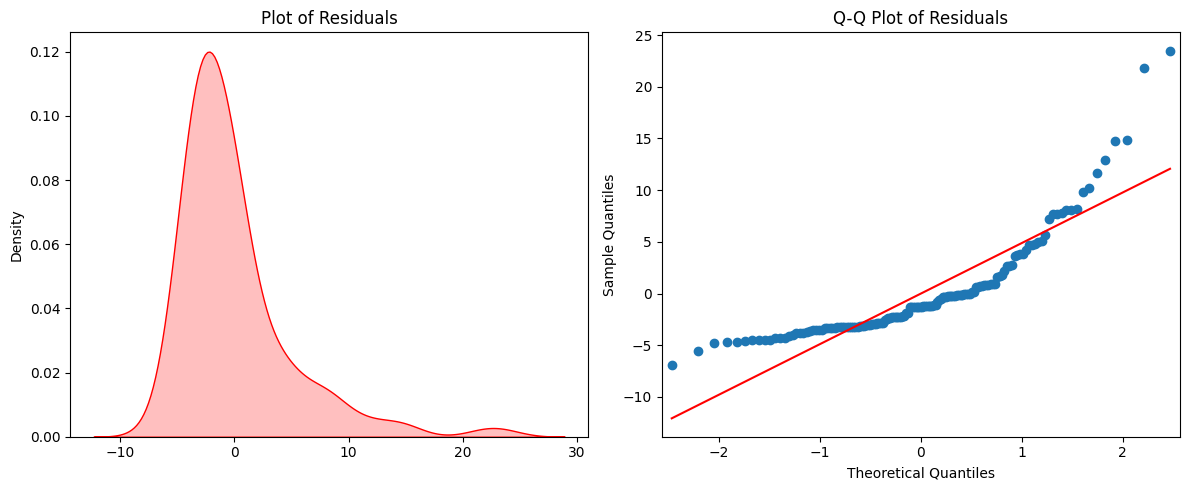

In [ ]:
import seaborn as sns
import statsmodels.api as sm

# Get residuals after fitting the model
residual_1 = model1_cov.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residual_1, ax=ax[0], color='red', fill=True)
ax[0].set_title('Plot of Residuals')

# Q-Q plot
sm.qqplot(residual_1, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')

# Plotting the graphs below
plt.tight_layout()
plt.show()

In [ ]:
# Perform Shapiro-Wilk test on residuals
shapiro_resid = stats.shapiro(residual_1.dropna())

print(f'W: {round(shapiro_resid[0], 3)}, P-value: {round(shapiro_resid[1], 3)}')

W: 0.787, P-value: 0.0


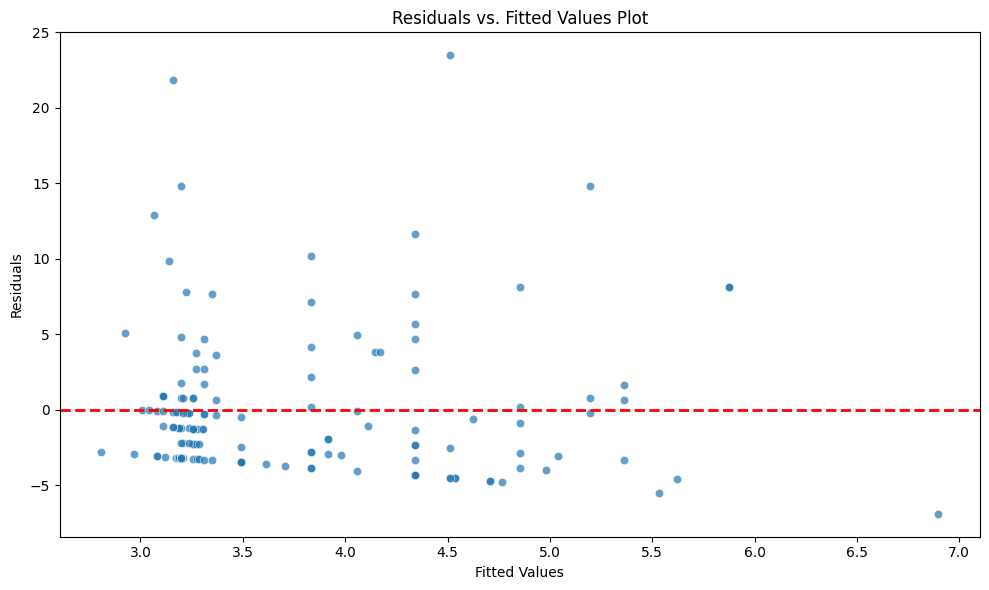

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Get the residuals and the fitted values
residual_1 = model1_cov.resid
fitted_value = model1_cov.fittedvalues

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_value, y=residual_1, alpha=0.7)
# Line at zero as a reference
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Residuals vs. Fitted Values Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

>**SOURCE FOR ANCOVA CODE:** https://www.reneshbedre.com/blog/ancova.html

Note: This is using the log transformed dependent variable.

In [ ]:
# Run ANCOVA with covariates (no blocking factor)
formula1_log_cov = 'Q("log_total") ~ C(treatment_nhc) + femalenhc_ratio + C(treatment_nhc):femalenhc_ratio'

# Fit the model using Ordinary Least Squares (OLS)
model1_log_cov = sm.formula.ols(formula1_log_cov, data = selected_participants1_cov).fit()

anova_cov1 = sm.stats.anova_lm(model1_log_cov, typ=2)

# Perform the Type III ANOVA and display the results
# Use typ=3 for Type III SS: used in ANCOVA because it tests the main effects and interactions, adjusting for the presence of other factors
aov_table = sm.stats.anova_lm(model1_log_cov, typ=3)
print(aov_table)
print(model1_log_cov.summary())

                                      sum_sq     df         F    PR(>F)
Intercept                           7.421789    1.0  8.822348  0.003495
C(treatment_nhc)                    0.181867    1.0  0.216187  0.642673
femalenhc_ratio                     0.276160    1.0  0.328274  0.567584
C(treatment_nhc):femalenhc_ratio    0.159660    1.0  0.189789  0.663754
Residual                          119.457319  142.0       NaN       NaN
                            OLS Regression Results                            
Dep. Variable:         Q("log_total")   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.7104
Date:                Mon, 14 Apr 2025   Prob (F-statistic):              0.547
Time:                        23:20:05   Log-Likelihood:                -192.52
No. Observations:                 146   AIC:                             393.0
Df Residuals:  

**Checking Assumptions for ANCOVA:**

> 1. IID: Independently & Identically distributed taken care of by random sampling.
2. Normality: Testing for normality of residuals after fitting the model using the Shapiro-Wilk test
3. Homoscedasticity: variances of the dependent variable should be approximately equal across the different groups using

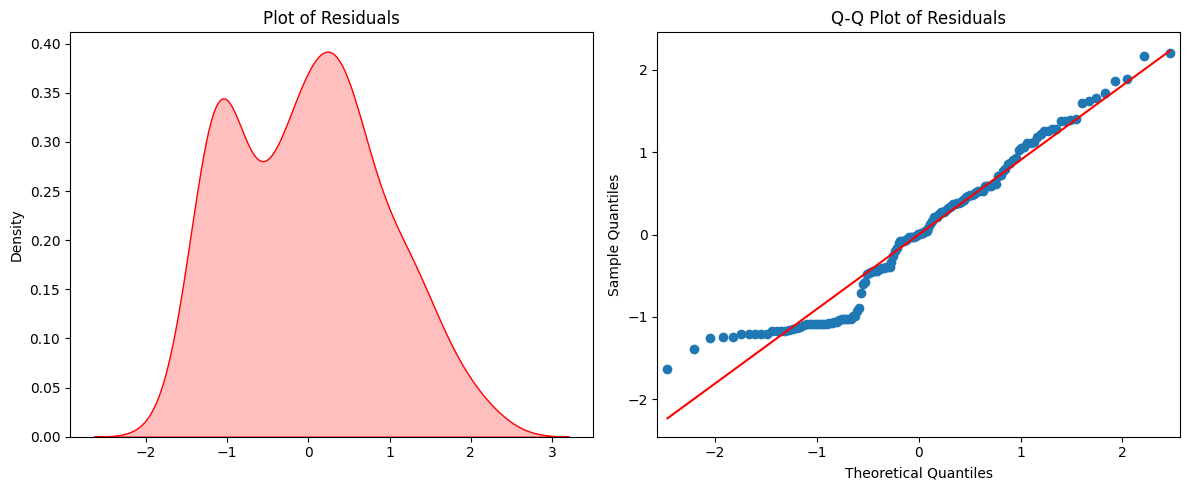

In [ ]:
import seaborn as sns
import statsmodels.api as sm

# Get residuals after fitting the model
residual_log_1 = model1_log_cov.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residual_log_1, ax=ax[0], color='red', fill=True)
ax[0].set_title('Plot of Residuals')

# Q-Q plot
sm.qqplot(residual_log_1, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')

# Plotting the graphs below
plt.tight_layout()
plt.show()

In [ ]:
# Perform Shapiro-Wilk test on residuals
shapiro_resid = stats.shapiro(residual_log_1.dropna())

print(f'W: {round(shapiro_resid[0], 3)}, P-value: {round(shapiro_resid[1], 3)}')

W: 0.955, P-value: 0.0


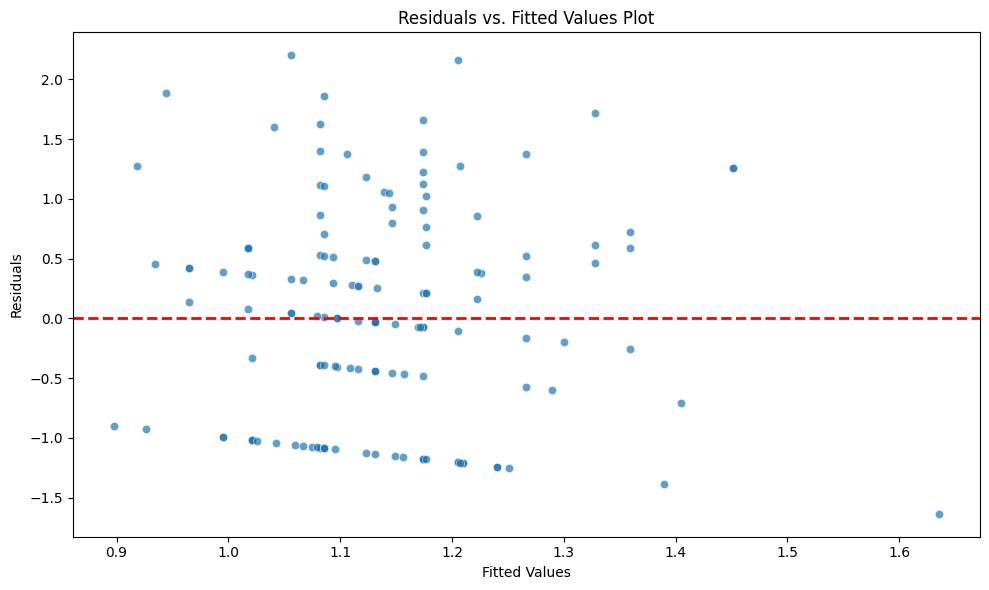

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Get the residuals and the fitted values
residual_log_1 = model1_log_cov.resid
fitted_value = model1_log_cov.fittedvalues

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_value, y=residual_log_1, alpha=0.7)
# Line at zero as a reference
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Residuals vs. Fitted Values Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

#**<mark>Section 2.6: Hypothesis #2 Description For FAC-Level</mark>** <br>
  | H0: Facilities where CBVs receive monetary incentives (treatment group) will have a significantly higher number of women seeking Antenatal Care (ANC) within the first trimester compared to facilities where CBVs work voluntarily (control group).<br>
  | HA: Facilities where CBVs receive monetary incentives (treatment group) will NOT have a significantly higher number of women seeking Antenatal Care (ANC) within the first trimester compared to facilities where CBVs work voluntarily (control group).<br>

Notes From Report 1: The incentive/treatment was monetary aid given to NHCs() for either referring or escorting women to seek ANC(Antenatal Care) within the first trimester(14 weeks). In the control health facilities, the status quo is maintained where CBVs support health service delivery on a voluntary basis with no monetary benefits. In the treatment health facilities,the CBVs are provided with monetary incentives.<br>

**Variables Used for Parallel Design Hypothesis 1:** <br>

Independent Variables: treatment_fac <br>
  - This variable indicates whether the facility received an intervention involving monetary incentives for the CBVs (treatment group) or not (control group). <br>
  - 1 represents the treatment group (i.e., facilities where Community-Based Volunteers (CBVs) receive incentives).
  - 0 represents the control group (i.e., facilities where CBVs do not receive incentives, and they continue to work on a voluntary basis).

Dependent Variable: <br>
  - 1st antenatal care number (1st trimester ) – total women who sought ANC at that facility over the entire period.

**<mark>Section 2.7: Initial Parallel Design Setup For Hypothesis 2</mark>** <br>

  1. Creating the required subset for parallel design on hypothesis 1. Participants are randomly assigned to either the treatment or control group. They remain in their assigned group throughout the study.To achieve medium effect, a total of 146 participants are selected from dataset. <br>

  2. Splitting the participants into either treatment or control. Random participants will be selected from the original dataset such that: <br>
    - Group 1 (Treatment - Incentives, 73 participants)
    - Group 2 (Control - No Incentives, 73 participants)

In [ ]:
import numpy as np
import pandas as pd

# Setting the seed for reproducibility
np.random.seed(42)

# Subset and label groups
parallel1_subset_df = merged_df[["treatment_fac", "anc_first_tri_num", "fid", "yr_month"]].copy()

# Create a new column 'Group_Label' in the dataframe based on the 'treatment_nhc' column
# If 'treatment_nhc' is 1, assign 'Treatment'; if 'treatment_nhc' is 0, assign 'Control'

# Initialize an empty list to store the new labels
group_labels = []

# Loop through each row in the 'treatment_nhc' column
for index, row in parallel1_subset_df.iterrows():
  # Check the value in the 'treatment_nhc' column
  if row['treatment_fac'] == 1:
    # If it's 1, append 'Treatment'
    group_labels.append('Treatment')
  else:
    # If it's 0, append 'Control'
    group_labels.append('Control')

# Add the list of labels as a new column in the dataframe
parallel1_subset_df['Group_Label'] = group_labels


# Split into Treatment and Control groups
treatment_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Treatment']
control_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Control']

# Randomly sample 73 from the split dataset for each of the group type
sample_treatment = treatment_df.sample(n=73, random_state=42, replace=True)
sample_control = control_df.sample(n=73, random_state=42, replace=True)

# Combine both samples
selected_participants2 = pd.concat([sample_treatment, sample_control], ignore_index=True)

# Checking to see if there are equal number of participants in both groups
print(selected_participants2['Group_Label'].value_counts())

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Displaying the selected subset of features and participants
selected_participants2.head()

Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

----------------------------------------------------------------------



,treatment_fac,anc_first_tri_num,fid,yr_month,Group_Label
0,1,89,118,201806,Treatment
1,1,47,18,202006,Treatment
2,1,42,115,201802,Treatment
3,1,19,122,202003,Treatment
4,1,47,18,201802,Treatment


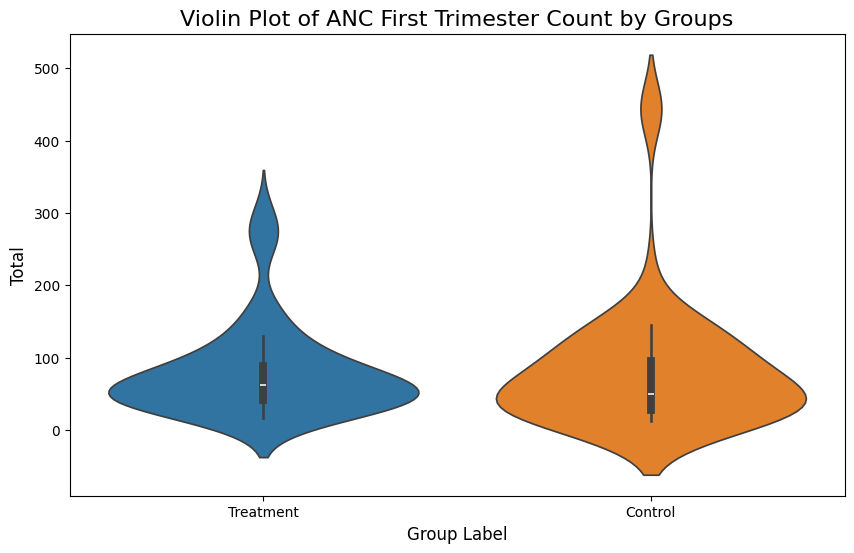

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the violin plot for Treatment and Control groups (using your 'Treatment' column)
plt.figure(figsize=(10, 6))
sns.violinplot(x="Group_Label", y="anc_first_tri_num", data=selected_participants2, hue="Group_Label",
               order=["Treatment", "Control"], legend=False)

# Adding the titles and labels to the plot
plt.title('Violin Plot of ANC First Trimester Count by Groups', fontsize=16)
plt.xlabel('Group Label', fontsize=12)
plt.ylabel('Total', fontsize=12)

# Displaying the plot
plt.show()

**<mark>Section 2.8: Parallel Design Setup With Blocking Factor For Hypothesis 2</mark>** <br>

Blocking Factor: facilitytype_fac

Reason: The outcome variable (i.e. facilitytype_fac) could be dependent on the type of facility that the womens are being placed in. We want to account for the variability within different types of facilities.

In [ ]:
# Get the unique levels for the blocking factor 'facilitytype_nhc'
blocking_factor_levels2 = merged_df['facilitytype_fac'].unique()
print(blocking_factor_levels2)

['Rural Health Centre', 'Health Post - Rural']
Categories (2, object): ['Health Post - Rural', 'Rural Health Centre']


In [ ]:
import numpy as np
import pandas as pd

# Setting the seed for reproducibility
np.random.seed(42)

# Subset and label groups
parallel1_subset_df = merged_df[["treatment_fac", "anc_first_tri_num", "fid", "yr_month", "facilitytype_fac"]].copy()

# Create a new column 'Group_Label' in the dataframe based on the 'treatment_nhc' column
# If 'treatment_nhc' is 1, assign 'Treatment'; if 'treatment_nhc' is 0, assign 'Control'

# Initialize an empty list to store the new labels
group_labels = []

# Loop through each row in the 'treatment_nhc' column
for index, row in parallel1_subset_df.iterrows():
  # Check the value in the 'treatment_nhc' column
  if row['treatment_fac'] == 1:
    # If it's 1, append 'Treatment'
    group_labels.append('Treatment')
  else:
    # If it's 0, append 'Control'
    group_labels.append('Control')

# Add the list of labels as a new column in the dataframe
parallel1_subset_df['Group_Label'] = group_labels

# Split the dataset by the blocking factor: Facility Type
facility1 = parallel1_subset_df[parallel1_subset_df['facilitytype_fac'] == 'Rural Health Centre']
facility2 = parallel1_subset_df[parallel1_subset_df['facilitytype_fac'] == 'Health Post - Rural']

# Sample 37 from each facility type for both Treatment and Control
sample_facility1_treatment = facility1[facility1['Group_Label'] == 'Treatment'].sample(n=37, random_state=42, replace=True)
sample_facility2_treatment = facility2[facility2['Group_Label'] == 'Treatment'].sample(n=37, random_state=42, replace=True)
sample_facility1_control   = facility1[facility1['Group_Label'] == 'Control'].sample(n=37, random_state=42, replace=True)
sample_facility2_control   = facility2[facility2['Group_Label'] == 'Control'].sample(n=37, random_state=42, replace=True)

# Combine all sampled data: here we have more samples than required (148) so we will randomly drop two to meet the 146 requirement
selected_participants2_block = pd.concat([sample_facility1_treatment, sample_facility1_control,sample_facility2_treatment, sample_facility2_control], ignore_index=True)

# Now from the combined dataset drop randomly a treatment and control row each
drop_treatment_idx = selected_participants2_block[selected_participants2_block['Group_Label'] == 'Treatment'].sample(n=1, random_state=42).index
drop_control_idx   = selected_participants2_block[selected_participants2_block['Group_Label'] == 'Control'].sample(n=1, random_state=42).index
# Drop the selected rows, now each group will contain 73 participants again
selected_participants2_block.drop(index=drop_treatment_idx, inplace=True)
selected_participants2_block.drop(index=drop_control_idx, inplace=True)

# Checking to see if there are equal number of participants in both groups
print(selected_participants2_block['Group_Label'].value_counts())

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Displaying the selected subset of features and participants
selected_participants2_block.head()

Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

----------------------------------------------------------------------



,treatment_fac,anc_first_tri_num,fid,yr_month,facilitytype_fac,Group_Label
0,1,70,30,201902,Rural Health Centre,Treatment
1,1,118,26,202003,Rural Health Centre,Treatment
2,1,22,55,201803,Rural Health Centre,Treatment
3,1,39,62,201903,Rural Health Centre,Treatment
5,1,17,24,201905,Rural Health Centre,Treatment


>**Checking for Normality of Dependent Variable: anc_first_tri_num**

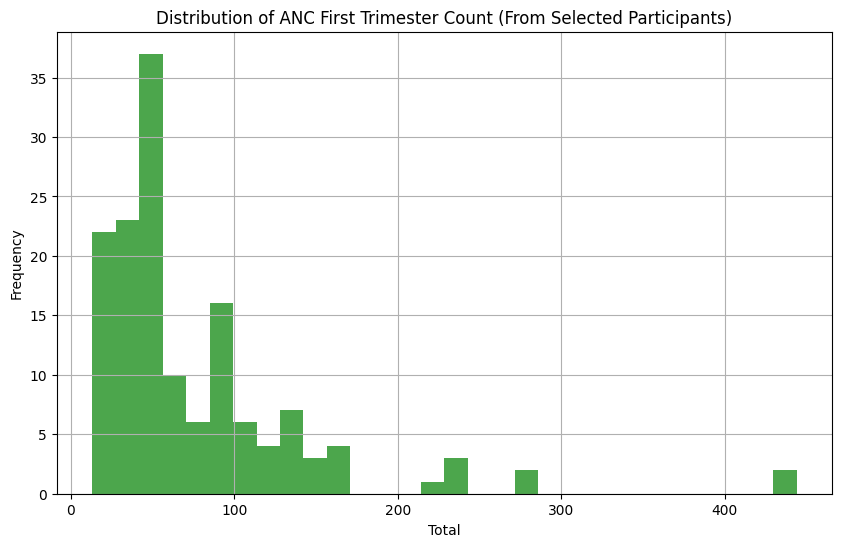

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram of the 'total' values in the selected sample
plt.figure(figsize=(10, 6))
plt.hist(selected_participants2_block['anc_first_tri_num'].dropna(), bins=30, color='green', alpha=0.7)

# Add title and axis labels
plt.title('Distribution of ANC First Trimester Count (From Selected Participants)')
plt.xlabel('Total')
plt.ylabel('Frequency')

# Add a grid for readability
plt.grid(True)

# Show the plot
plt.show()

>**Violin Plot to Display the Distribution after the Blocking & Randomization for Parallel Design**

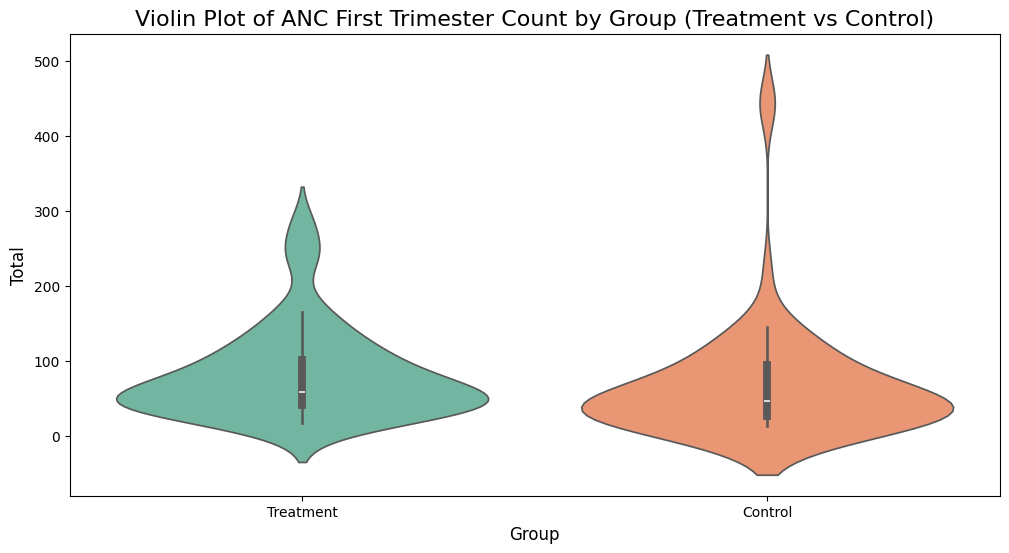

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Group_Label", y="anc_first_tri_num", data=selected_participants2_block, hue="Group_Label",
               order=["Treatment", "Control"], palette="Set2")

# Add title and labels
plt.title('Violin Plot of ANC First Trimester Count by Group (Treatment vs Control)', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Total', fontsize=12)

# Show the plot
plt.show()

>**Boxplot: A more clear visualization of the distribution after separating into different Facility levels and Incentive types (i.e. treatment/control groups)**

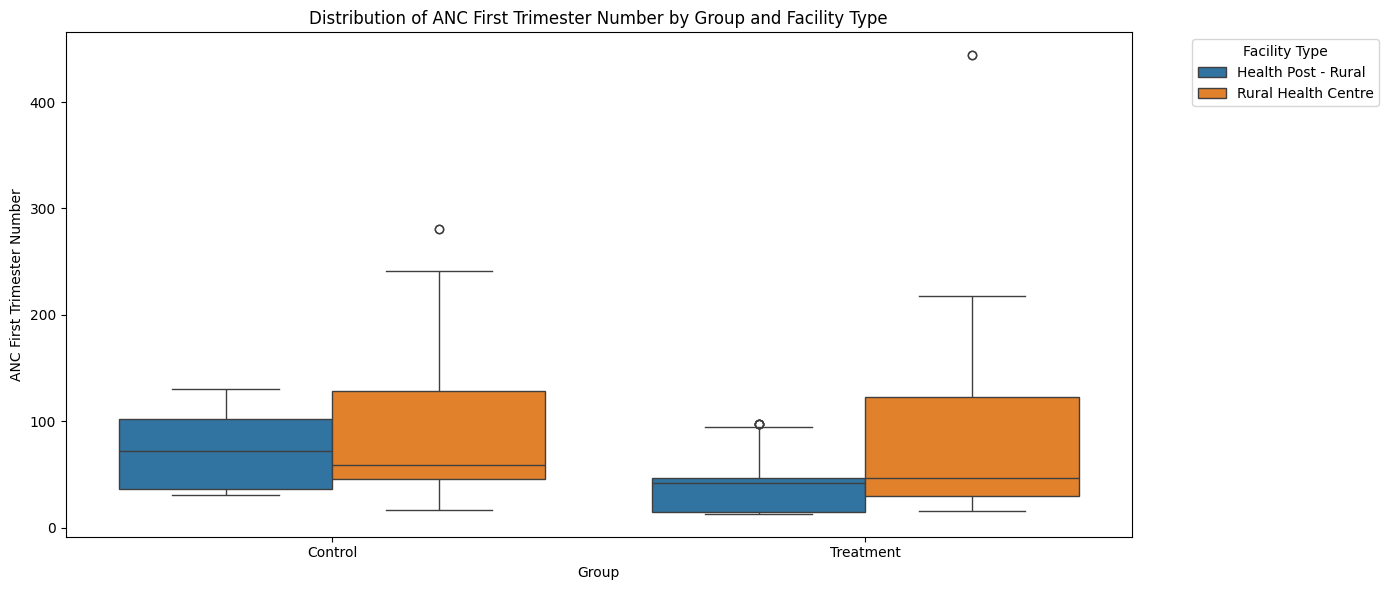

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values if any (optional safety step)
cleaned_df = selected_participants2_block.dropna(subset=['anc_first_tri_num', 'Group_Label', 'facilitytype_fac'])

# Create the boxplot
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=cleaned_df, x="Group_Label", y="anc_first_tri_num", hue="facilitytype_fac")

# Customize x-axis tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Treatment'], rotation=0)

# Customize the plot (labels, title, etc.)
ax.set_title('Distribution of ANC First Trimester Number by Group and Facility Type')
ax.set_xlabel('Group')
ax.set_ylabel('ANC First Trimester Number')

# Add legend
plt.legend(title='Facility Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show plot
plt.show()

>**TWO-WAY ANOVA & SUMMARY STATISTICS: After blocking using facility type level and then randomly assigning each participant into two groups (i.e. treatment/control) we use two-way ANOVA to find the significance of the blocking factor based on the p-value**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Example formula using variables from your dataset
formula2 = 'anc_first_tri_num ~ Group_Label + facilitytype_fac + Group_Label:facilitytype_fac'

# Fit the model
model2 = ols(formula2, data=selected_participants2_block).fit()

# Perform ANOVA and print table
aov_table = sm.stats.anova_lm(model2)
print(aov_table)

# Print the model summary
print(model2.summary())

                                 df         sum_sq       mean_sq         F  \
Group_Label                     1.0   10667.835616  10667.835616  2.371861   
facilitytype_fac                1.0   41709.572427  41709.572427  9.273606   
Group_Label:facilitytype_fac    1.0    4394.299894   4394.299894  0.977018   
Residual                      142.0  638668.401652   4497.664800       NaN   

                                PR(>F)  
Group_Label                   0.125765  
facilitytype_fac              0.002772  
Group_Label:facilitytype_fac  0.324617  
Residual                           NaN  
                            OLS Regression Results                            
Dep. Variable:      anc_first_tri_num   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     4.207
Date:                Mon, 14 Apr 2025   Prob (F-statistic):            0.00694
Time:    

**TUKEY'S HSD TEST: Post-hoc analysis following Two-Way ANOVA**

> SOURCE: https://campus.datacamp.com/courses/experimental-design-in-python/analyzing-experimental-data-statistical-tests-and-power?ex=5

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey's HSD test for Group_Label
tukey_group1 = pairwise_tukeyhsd(endog=selected_participants2_block['anc_first_tri_num'], groups=selected_participants2_block['Group_Label'], alpha=0.05)

print("\nTukey HSD Test Results for Group_Label (Treatment vs Control):")
print(tukey_group1)


Tukey HSD Test Results for Group_Label (Treatment vs Control):
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
Control Treatment  17.0959 0.1364 -5.4651 39.6569  False
--------------------------------------------------------


**Checking Assumptions for Two-Way ANOVA:**

> 1. IID: Independently & Identically distributed taken care of by random sampling.
2. Normality: Testing for normality of residuals after fitting the model using the Shapiro-Wilk test
3. Homoscedasticity: variances of the dependent variable should be approximately equal across the different groups using

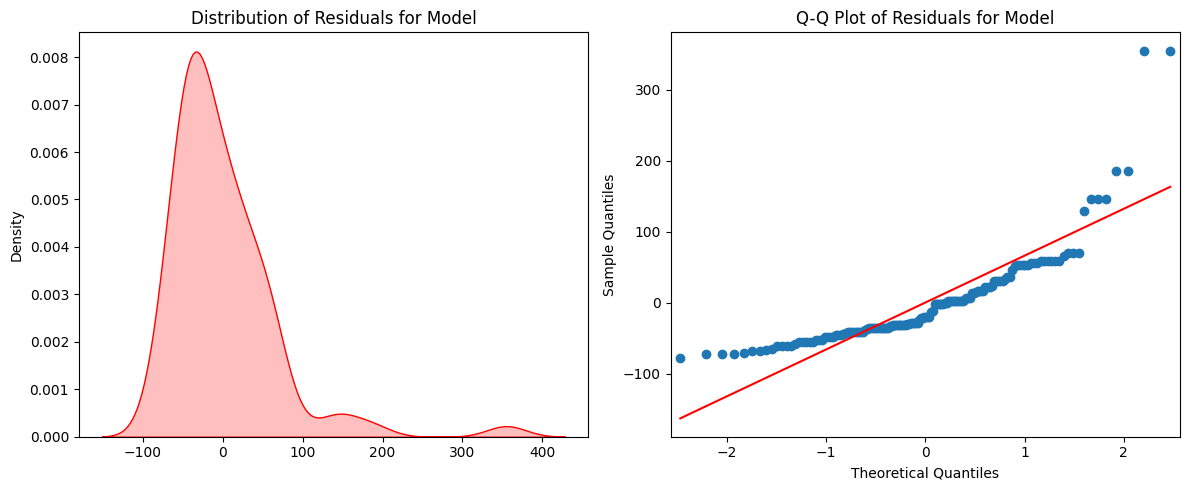

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get residuals after fitting the model
residuals2_block = model2.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residuals2_block, ax=ax[0], color='red', fill=True)
ax[0].set_title('Distribution of Residuals for Model')

# Q-Q plot
sm.qqplot(residuals2_block, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals for Model')

# Plotting the graphs
plt.tight_layout()
plt.show()

>**Performing Shapiro-Wilk test on residuals after fitting the model to check for assumption of normality.**

In [ ]:
from scipy import stats

# Perform Shapiro-Wilk test on residuals
shapiro_res = stats.shapiro(residuals2_block.dropna())

print(f'W: {round(shapiro_res[0], 3)}, P-value: {round(shapiro_res[1], 3)}')

W: 0.77, P-value: 0.0


> **<mark>The dependent variable (i.e. anc_first_tri_num) doesn't follow normal distribution, hence, we must log transform it. Everything below this (i.e. for section 2.8) uses the log-transformed total**

In [ ]:
selected_participants2_block['log_anc_first_tri_num'] = np.log(selected_participants2_block['anc_first_tri_num'] + 1)
selected_participants2_block.head()

,treatment_fac,anc_first_tri_num,fid,yr_month,facilitytype_fac,Group_Label,log_anc_first_tri_num
0,1,70,30,201902,Rural Health Centre,Treatment,4.262680
1,1,118,26,202003,Rural Health Centre,Treatment,4.779123
2,1,22,55,201803,Rural Health Centre,Treatment,3.135494
3,1,39,62,201903,Rural Health Centre,Treatment,3.688879
5,1,17,24,201905,Rural Health Centre,Treatment,2.890372


>**Checking for Normality of Log-Transformed Dependent Variable: anc_first_tri_num**

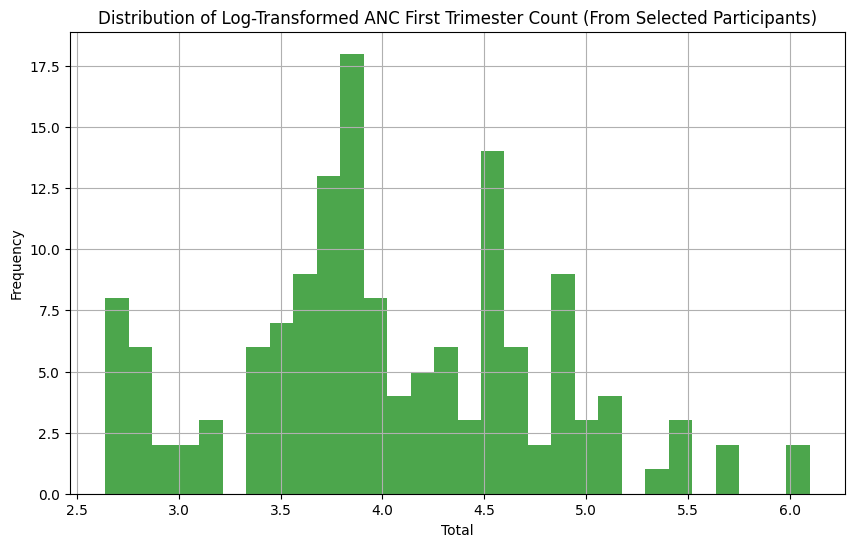

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram of the 'total' values in the selected sample
plt.figure(figsize=(10, 6))
plt.hist(selected_participants2_block['log_anc_first_tri_num'].dropna(), bins=30, color='green', alpha=0.7)

# Add title and axis labels
plt.title('Distribution of Log-Transformed ANC First Trimester Count (From Selected Participants)')
plt.xlabel('Total')
plt.ylabel('Frequency')

# Add a grid for readability
plt.grid(True)

# Show the plot
plt.show()

>**Violin Plot to Display the Distribution after the Blocking & Randomization for Parallel Design**

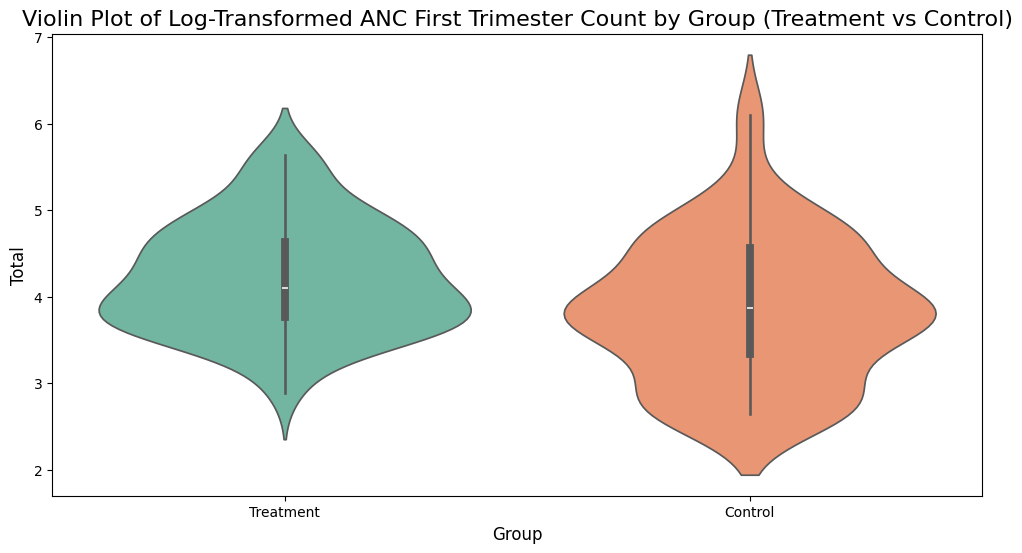

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Group_Label", y="log_anc_first_tri_num", data=selected_participants2_block, hue="Group_Label",
               order=["Treatment", "Control"], palette="Set2")

# Add title and labels
plt.title('Violin Plot of Log-Transformed ANC First Trimester Count by Group (Treatment vs Control)', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Total', fontsize=12)

# Show the plot
plt.show()

>**Boxplot: A more clear visualization of the distribution after separating into different Facility levels and Incentive types (i.e. treatment/control groups)**

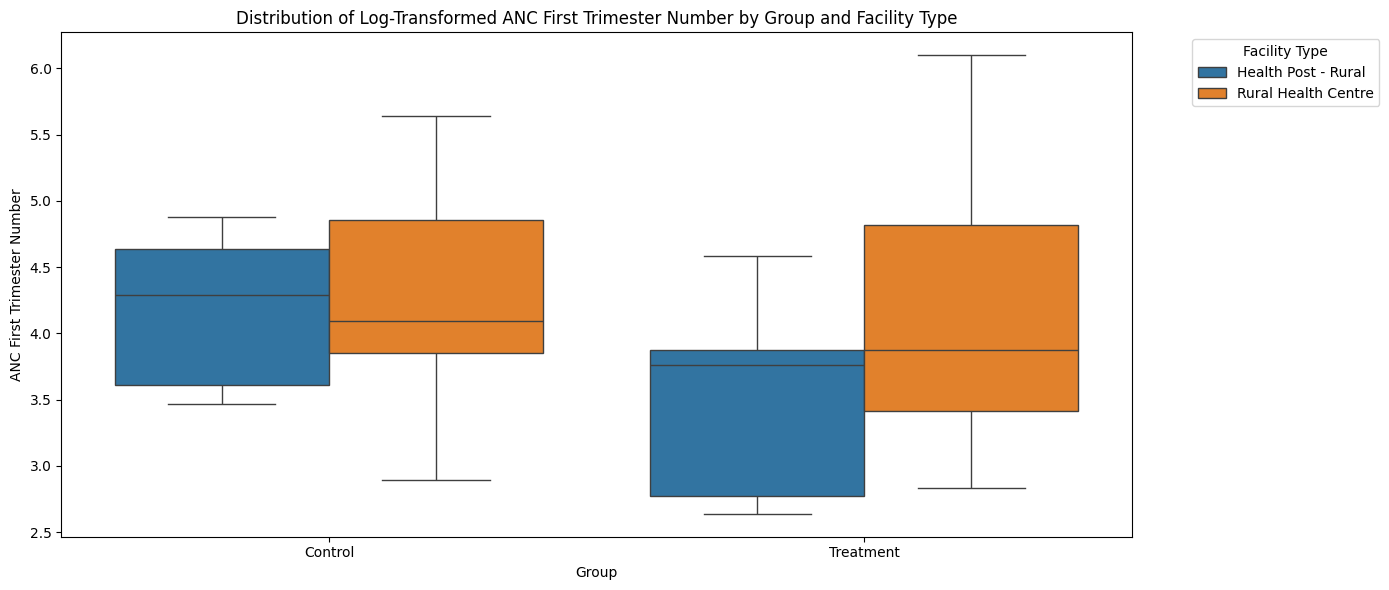

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values if any (optional safety step)
cleaned_df = selected_participants2_block.dropna(subset=['log_anc_first_tri_num', 'Group_Label', 'facilitytype_fac'])

# Create the boxplot
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=cleaned_df, x="Group_Label", y="log_anc_first_tri_num", hue="facilitytype_fac")

# Customize x-axis tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Treatment'], rotation=0)

# Customize the plot (labels, title, etc.)
ax.set_title('Distribution of Log-Transformed ANC First Trimester Number by Group and Facility Type')
ax.set_xlabel('Group')
ax.set_ylabel('ANC First Trimester Number')

# Add legend
plt.legend(title='Facility Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show plot
plt.show()

>**TWO-WAY ANOVA & SUMMARY STATISTICS AFTER LOG-TRASFORMATION: After blocking using facility type level and then randomly assigning each participant into two groups (i.e. treatment/control) we use two-way ANOVA to find the significance of the blocking factor based on the p-value**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Example formula using variables from your dataset
formula2_log = 'anc_first_tri_num ~ Group_Label + facilitytype_fac + Group_Label:facilitytype_fac'

# Fit the model
model2_log = ols(formula2_log, data=selected_participants2_block).fit()

# Perform ANOVA and print table
aov_table = sm.stats.anova_lm(model2_log)
print(aov_table)

# Print the model summary
print(model2_log.summary())

                                 df         sum_sq       mean_sq         F  \
Group_Label                     1.0   10667.835616  10667.835616  2.371861   
facilitytype_fac                1.0   41709.572427  41709.572427  9.273606   
Group_Label:facilitytype_fac    1.0    4394.299894   4394.299894  0.977018   
Residual                      142.0  638668.401652   4497.664800       NaN   

                                PR(>F)  
Group_Label                   0.125765  
facilitytype_fac              0.002772  
Group_Label:facilitytype_fac  0.324617  
Residual                           NaN  
                            OLS Regression Results                            
Dep. Variable:      anc_first_tri_num   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     4.207
Date:                Mon, 14 Apr 2025   Prob (F-statistic):            0.00694
Time:    

**TUKEY'S HSD TEST: Post-hoc analysis following Two-Way ANOVA After Log-Transforming**

> SOURCE: https://campus.datacamp.com/courses/experimental-design-in-python/analyzing-experimental-data-statistical-tests-and-power?ex=5

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey's HSD test for Group_Label
tukey_group1 = pairwise_tukeyhsd(endog=selected_participants2_block['log_anc_first_tri_num'], groups=selected_participants2_block['Group_Label'], alpha=0.05)

print("\nTukey HSD Test Results for Group_Label (Treatment vs Control):")
print(tukey_group1)


Tukey HSD Test Results for Group_Label (Treatment vs Control):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower  upper  reject
------------------------------------------------------
Control Treatment   0.3867 0.0018 0.1462 0.6271   True
------------------------------------------------------


**Checking Assumptions for Two-Way ANOVA:**

> 1. IID: Independently & Identically distributed taken care of by random sampling.
2. Normality: Testing for normality of residuals after fitting the model using the Shapiro-Wilk test
3. Homoscedasticity: variances of the dependent variable should be approximately equal across the different groups using

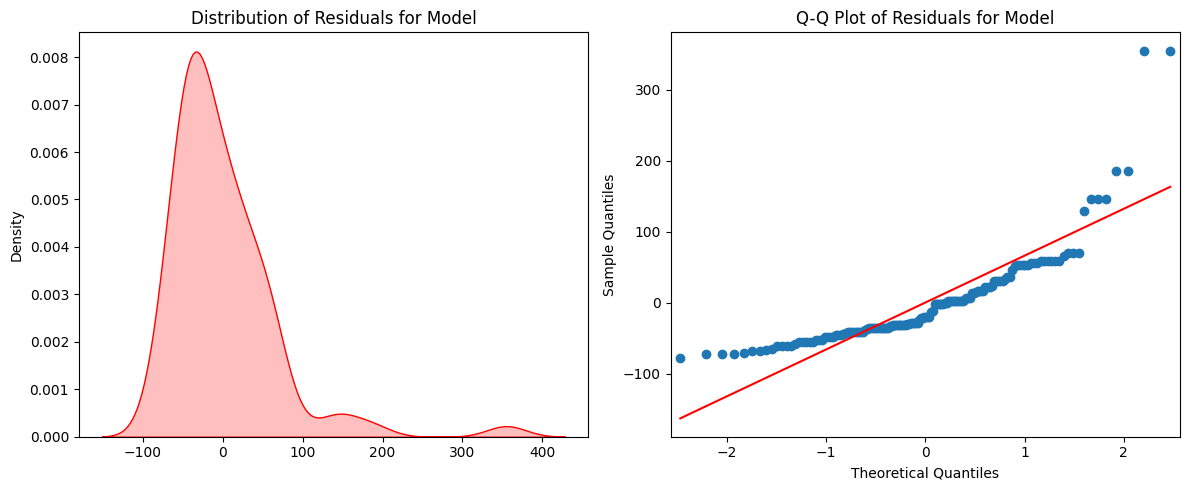

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get residuals after fitting the model
residuals2_block_log = model2_log.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residuals2_block_log, ax=ax[0], color='red', fill=True)
ax[0].set_title('Distribution of Residuals for Model')

# Q-Q plot
sm.qqplot(residuals2_block_log, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals for Model')

# Plotting the graphs
plt.tight_layout()
plt.show()

>**Performing Shapiro-Wilk test on residuals after fitting the model to check for assumption of normality.**

In [ ]:
from scipy import stats

# Perform Shapiro-Wilk test on residuals
shapiro_res = stats.shapiro(residuals2_block_log.dropna())

print(f'W: {round(shapiro_res[0], 3)}, P-value: {round(shapiro_res[1], 3)}')

W: 0.77, P-value: 0.0


**<mark>Section 2.9: Parallel Design Setup With Continuous Covariates (exluding blocking factor) For Hypothesis 2</mark>** <br>

> **Covariate Used:** `no_maternity_beds` & `distance_dmo` </br>

> **Subset Requirement:** We add the new continuous covariate variable into our subset but use the parallel design from the original setup.

> **GLM Requirements:** We removed `facilitytype_fac` (used previously as a blocking factor) to isolate the effect of these numeric covariates in a GLM framework.
  - The availability of maternity beds could influence how many women can be accommodated at a given time, affecting the facility's ability to provide ANC services. A higher number of maternity beds might lead to a higher capacity for ANC services, which could influence the number of women seeking ANC and, consequently, the number of women referred by CBVs.
  - The distance to the District Medical Office (DMO) could affect the accessibility of healthcare services, including ANC. If a facility is farther from the DMO, it might face challenges in providing ANC services or facilitating referrals, which could influence the outcome.

In [ ]:
import numpy as np
import pandas as pd

# Setting the seed for reproducibility
np.random.seed(42)

# Subset and label groups
parallel1_subset_df = merged_df[["treatment_fac", "anc_first_tri_num", "fid", "yr_month", "no_maternity_beds", "distance_dmo"]].copy()

# Create a new column 'Group_Label' in the dataframe based on the 'treatment_nhc' column
# If 'treatment_nhc' is 1, assign 'Treatment'; if 'treatment_nhc' is 0, assign 'Control'

# Initialize an empty list to store the new labels
group_labels = []

# Loop through each row in the 'treatment_nhc' column
for index, row in parallel1_subset_df.iterrows():
  # Check the value in the 'treatment_nhc' column
  if row['treatment_fac'] == 1:
    # If it's 1, append 'Treatment'
    group_labels.append('Treatment')
  else:
    # If it's 0, append 'Control'
    group_labels.append('Control')

# Add the list of labels as a new column in the dataframe
parallel1_subset_df['Group_Label'] = group_labels


# Split into Treatment and Control groups
treatment_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Treatment']
control_df = parallel1_subset_df[parallel1_subset_df['Group_Label'] == 'Control']

# Randomly sample 73 from the split dataset for each of the group type
sample_treatment = treatment_df.sample(n=73, random_state=42, replace=True)
sample_control = control_df.sample(n=73, random_state=42, replace=True)

# Combine both samples
selected_participants2_cov = pd.concat([sample_treatment, sample_control], ignore_index=True)

# Checking to see if there are equal number of participants in both groups
print(selected_participants2_cov['Group_Label'].value_counts())

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Displaying the selected subset of features and participants
selected_participants2_cov.head()

Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

----------------------------------------------------------------------



,treatment_fac,anc_first_tri_num,fid,yr_month,no_maternity_beds,distance_dmo,Group_Label
0,1,89,118,201806,2,25.0,Treatment
1,1,47,18,202006,5,27.0,Treatment
2,1,42,115,201802,2,34.0,Treatment
3,1,19,122,202003,1,52.0,Treatment
4,1,47,18,201802,5,27.0,Treatment


>**SOURCE FOR ANCOVA CODE:** https://www.reneshbedre.com/blog/ancova.html

Note: This is using the dependent variable without log transformation.

In [ ]:
# Run ANCOVA with covariates (no blocking factor)
formula3_cov = 'Q("anc_first_tri_num") ~ C(treatment_fac) + no_maternity_beds + distance_dmo + C(treatment_fac):no_maternity_beds + C(treatment_fac):distance_dmo + no_maternity_beds:distance_dmo'

# Fit the model using Ordinary Least Squares (OLS)
model2_cov = sm.formula.ols(formula3_cov, data = selected_participants2_cov).fit()

anova_cov2 = sm.stats.anova_lm(model2_cov, typ=2)
# Perform the Type III ANOVA and display the results
# Use typ=3 for Type III SS: used in ANCOVA because it tests the main effects and interactions, adjusting for the presence of other factors
aov_table = sm.stats.anova_lm(model2_cov, typ=3)
print(aov_table)
print(model2_cov.summary())

                                           sum_sq     df         F    PR(>F)
Intercept                            27167.496058    1.0  4.541955  0.034833
C(treatment_fac)                      3288.690970    1.0  0.549815  0.459644
no_maternity_beds                     9106.614597    1.0  1.522475  0.219328
C(treatment_fac):no_maternity_beds   17511.478357    1.0  2.927629  0.089306
distance_dmo                          4096.128879    1.0  0.684805  0.409356
C(treatment_fac):distance_dmo         2918.893501    1.0  0.487991  0.485992
no_maternity_beds:distance_dmo           0.885228    1.0  0.000148  0.990311
Residual                            831422.102710  139.0       NaN       NaN
                              OLS Regression Results                              
Dep. Variable:     Q("anc_first_tri_num")   R-squared:                       0.032
Model:                                OLS   Adj. R-squared:                 -0.010
Method:                     Least Squares   F-statistic:  

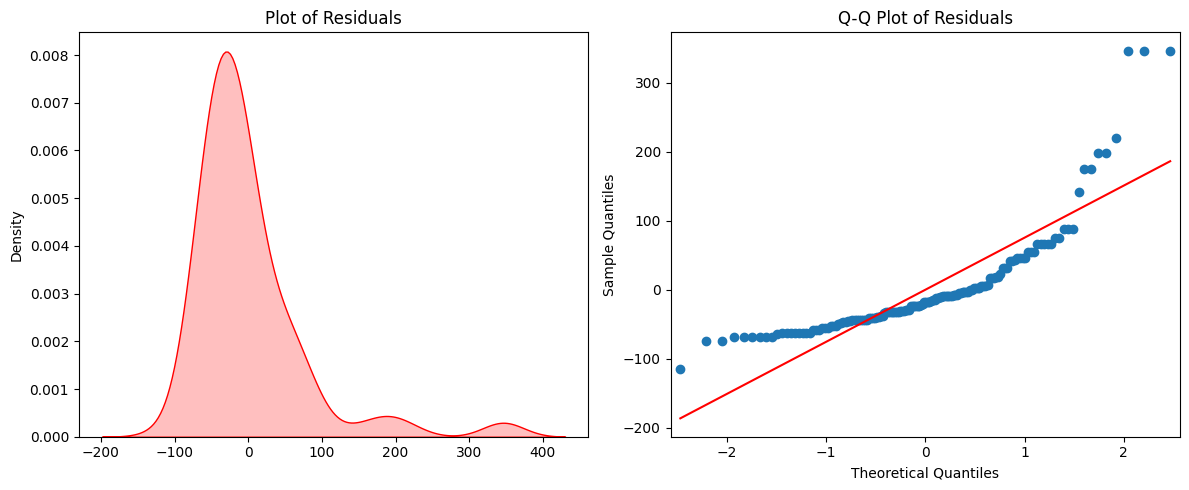

In [ ]:
import seaborn as sns
import statsmodels.api as sm

# Get residuals after fitting the model
residual_2_cov = model2_cov.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residual_2_cov, ax=ax[0], color='red', fill=True)
ax[0].set_title('Plot of Residuals')

# Q-Q plot
sm.qqplot(residual_2_cov, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')

# Plotting the graphs below
plt.tight_layout()
plt.show()

In [ ]:
# Perform Shapiro-Wilk test on residuals
shapiro_resid = stats.shapiro(residual_2_cov.dropna())

print(f'W: {round(shapiro_resid[0], 3)}, P-value: {round(shapiro_resid[1], 3)}')

W: 0.741, P-value: 0.0


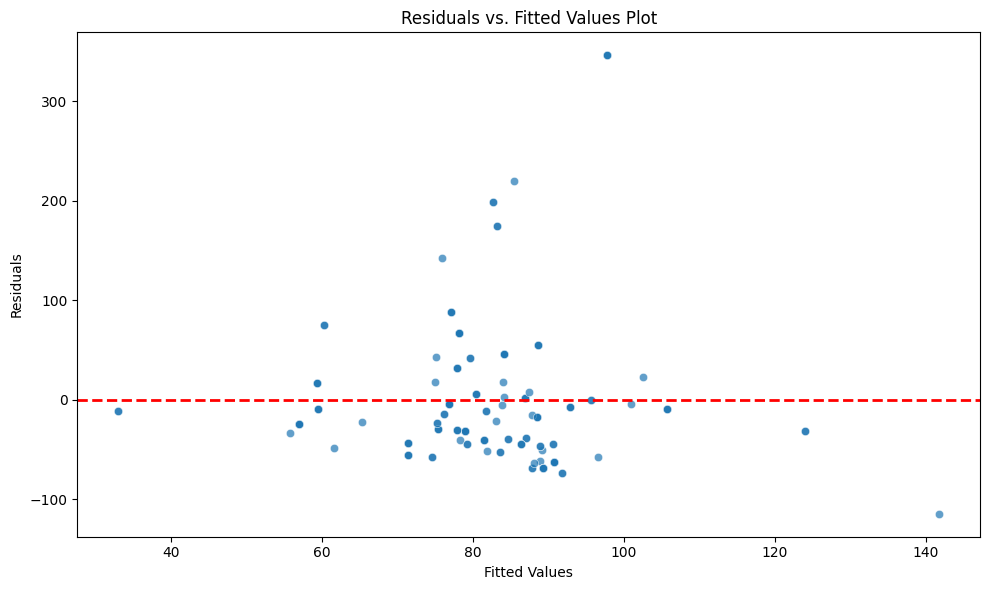

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Get the residuals and the fitted values
residual_2_cov = model2_cov.resid
fitted_value = model2_cov.fittedvalues

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_value, y=residual_2_cov, alpha=0.7)
# Line at zero as a reference
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Residuals vs. Fitted Values Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

**Log transformation of dependent variable in an attempt to fix the normality assumption**

In [ ]:
selected_participants2_cov['log_anc_first_tri_num'] = np.log(selected_participants2_cov['anc_first_tri_num'] + 1)
selected_participants2_cov.head()

,treatment_fac,anc_first_tri_num,fid,yr_month,no_maternity_beds,distance_dmo,Group_Label,log_anc_first_tri_num
0,1,89,118,201806,2,25.0,Treatment,4.499810
1,1,47,18,202006,5,27.0,Treatment,3.871201
2,1,42,115,201802,2,34.0,Treatment,3.761200
3,1,19,122,202003,1,52.0,Treatment,2.995732
4,1,47,18,201802,5,27.0,Treatment,3.871201


>**SOURCE FOR ANCOVA CODE:** https://www.reneshbedre.com/blog/ancova.html

Note: This is using the dependent variable after the log-transformation.

In [ ]:
# Run ANCOVA with covariates (no blocking factor)
formula3_cov_log = 'Q("log_anc_first_tri_num") ~ C(treatment_fac) + no_maternity_beds + distance_dmo + C(treatment_fac):no_maternity_beds + C(treatment_fac):distance_dmo + no_maternity_beds:distance_dmo'

# Fit the model using Ordinary Least Squares (OLS)
model2_cov_log = sm.formula.ols(formula3_cov_log, data = selected_participants2_cov).fit()

anova_cov2 = sm.stats.anova_lm(model2_cov_log, typ=2)
# Perform the Type III ANOVA and display the results
# Use typ=3 for Type III SS: used in ANCOVA because it tests the main effects and interactions, adjusting for the presence of other factors
aov_table = sm.stats.anova_lm(model2_cov_log, typ=3)
print(aov_table)
print(model2_cov_log.summary())

                                       sum_sq     df           F        PR(>F)
Intercept                           75.787701    1.0  137.921208  1.491881e-22
C(treatment_fac)                     2.231897    1.0    4.061688  4.579454e-02
no_maternity_beds                    2.027979    1.0    3.690590  5.676741e-02
C(treatment_fac):no_maternity_beds   2.380206    1.0    4.331585  3.924601e-02
distance_dmo                         0.009838    1.0    0.017903  8.937522e-01
C(treatment_fac):distance_dmo        0.083844    1.0    0.152583  6.966772e-01
no_maternity_beds:distance_dmo       0.270689    1.0    0.492609  4.839394e-01
Residual                            76.380497  139.0         NaN           NaN
                                OLS Regression Results                                
Dep. Variable:     Q("log_anc_first_tri_num")   R-squared:                       0.055
Model:                                    OLS   Adj. R-squared:                  0.014
Method:                     

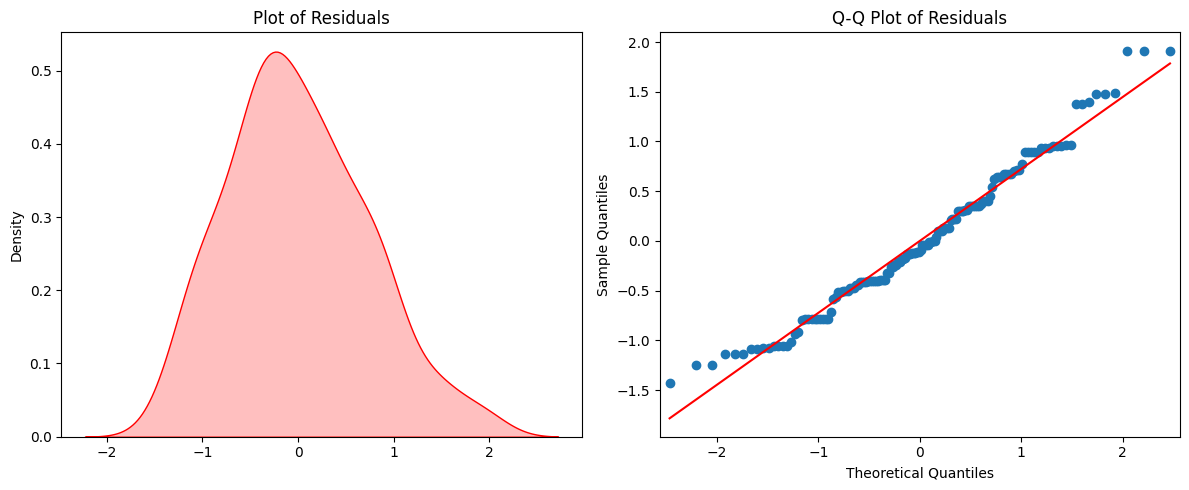

In [ ]:
import seaborn as sns
import statsmodels.api as sm

# Get residuals after fitting the model
residual_2_cov_log = model2_cov_log.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residual_2_cov_log, ax=ax[0], color='red', fill=True)
ax[0].set_title('Plot of Residuals')

# Q-Q plot
sm.qqplot(residual_2_cov_log, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')

# Plotting the graphs below
plt.tight_layout()
plt.show()

In [ ]:
# Perform Shapiro-Wilk test on residuals
shapiro_resid = stats.shapiro(residual_2_cov_log.dropna())

print(f'W: {round(shapiro_resid[0], 3)}, P-value: {round(shapiro_resid[1], 3)}')

W: 0.977, P-value: 0.013


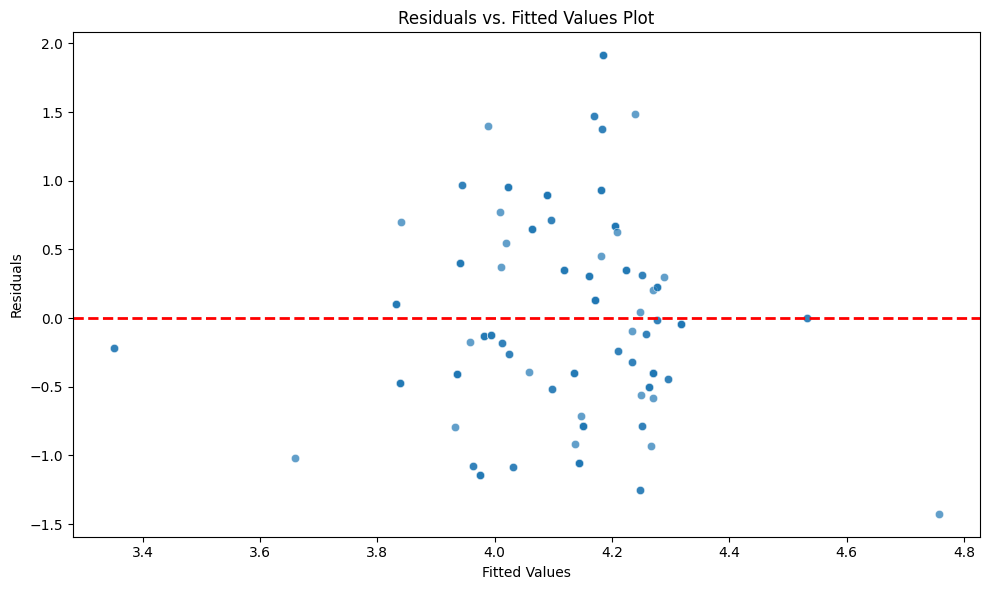

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Get the residuals and the fitted values
residual_2_cov_log = model2_cov_log.resid
fitted_value = model2_cov_log.fittedvalues

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_value, y=residual_2_cov_log, alpha=0.7)
# Line at zero as a reference
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Residuals vs. Fitted Values Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

#**3. Matched Pair Design**

In [ ]:
fac_clean_2020.head()

,treatment,facilitytype,pop_catchment,no_maternity_beds,distance_dmo,institutionaldeliveries,institutionaldeliverycoverage,stanccoverage1sttrimester,anc_first_tri_num,pair,yr_month,fid,d
24,0,Rural Health Centre,7751,1,95.0,10.0,53.7,4.4,50,42,202001,3,Chibombo
25,0,Rural Health Centre,7751,1,95.0,5.0,44.7,6.3,50,42,202002,3,Chibombo
26,0,Rural Health Centre,7751,1,95.0,8.0,25.4,13.3,50,42,202003,3,Chibombo
27,0,Rural Health Centre,7751,1,95.0,4.0,26.2,7.6,50,42,202004,3,Chibombo
28,0,Rural Health Centre,7751,1,95.0,10.0,55.2,10.3,50,42,202005,3,Chibombo


In [ ]:
# Counts the # of rows for the merged dataframe
n_rows = len(fac_clean_2020)
# Print the number of rows
print('The number of rows in merged_df:',n_rows)

The number of rows in merged_df: 471


**<mark>Section 3.1: Hypothesis #1 Description Facility-Level</mark>** <br>
  | H0: The intervention/treatment (incentives for CBVs) will lead to an increase in the total number of women sought antenatal care at that facility over the entire period. <br>
  | HA: The intervention/treatment (incentives for CBVs) will NOT lead to an increase in the total number of women sought antenatal care at that facility over the entire period. <br>

Notes From Report 1: The incentive/treatment was monetary aid given to NHCs() for either referring or escorting women to seek ANC(Antenatal Care) within the first trimester(14 weeks). In the control health facilities, the status quo is maintained where CBVs support health service delivery on a voluntary basis with no monetary benefits. In the treatment health facilities,the CBVs are provided with monetary incentives.<br>

**Variables Used for Matched Pair Design Hypothesis 1:** <br>

Independent Variables: treatment_nhc <br>
  - This variable indicates whether the facility received an intervention involving monetary incentives for the CBVs (treatment group) or not (control group). <br>
  - 1 represents the treatment group (i.e., facilities where Community-Based Volunteers (CBVs) receive incentives).
  - 0 represents the control group (i.e., facilities where CBVs do not receive incentives, and they continue to work on a voluntary basis).

Dependent Variable: Anc_first_tri_num <br>
  - This represents the total women who sought ANC at that facility over the entire period<br>

**<mark>Section 3.2: Power Analysis, Sample Size, & Associated Graph</mark>** </br>
>Effect Size: Medium (0.5)</br>
Power: 0.85 <br>
Total Sample Size: 146 </br>

In [ ]:
from statsmodels.stats.power import TTestIndPower

# Power Analysis for Matched Pair Design Scenario

# Medium effect size
effect_size = 0.5
# Significance level
alpha = 0.05
# Power value
power = 0.85
# matched pair design
number_groups = 2

# Creating a power analysis object
analysis = TTestIndPower()

# Calculating the required sample size per group
result = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)

# Rounding to get integer sample size
required_sample_size_per_group = round(result)

# Total sample size required for the experiment
total_sample_size = required_sample_size_per_group * number_groups

# Output the result
print(f'Required sample size per group: {required_sample_size_per_group}')
print(f'Total sample size for all groups: {total_sample_size}')

Required sample size per group: 73
Total sample size for all groups: 146


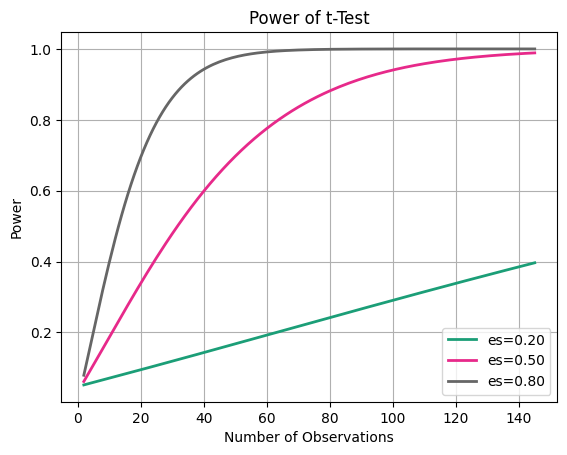

In [ ]:
from numpy import array
from matplotlib import pyplot

# Effect sizes: small (0.2), medium (0.5), large (0.8)
effect_sizes = array([0.2, 0.5, 0.8])

# Sample sizes: range from 2 to 146
sample_sizes = array(range(2, 146))

# Create a power analysis object for t-tests
analysis = TTestIndPower()

# Plot power curves
analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes, alpha=0.05, title='Power of t-Test')

# Formatting the plot
pyplot.grid()
pyplot.ylabel('Power')
pyplot.show()

**<mark>3.3 Matched Pair Design Setup For Hypothesis 1:</mark>** <br>


1.   Using "number of maternity beds" and "population in catchment area" and "distance to district medical office" as the matching criteria to form matched pairs of facilities, the general goal is to pair facilities that are similar in these criteria.

2. Splitting the facilities into either treatment or control(original matched pair design:  <br>
    - Group 1 (Treatment - Incentives, 49 participants)
    - Group 2 (Control - No Incentives, 49 participants)

3. To achieve medium effect, a total of 146 participants should be selected from the merged data to form 73 pairs. However, to follow the original design, there is only a sum of 98 facilities which leads to 49 pairs.

In [ ]:
# Create a new dataframe called matched_pair_subset_df from fac_clean_2020
matched_pair_subset_df = fac_clean_2020.copy()

# Create group labels based on the 'treatment' column
group_labels = []
for index, row in matched_pair_subset_df.iterrows():
    if row['treatment'] == 1:
        group_labels.append('Treatment')
    else:
        group_labels.append('Control')

# Add the labels as a new column
matched_pair_subset_df['Group_Label'] = group_labels

# Optional: sort by pair and treatment for easier viewing
matched_pair_subset_df = matched_pair_subset_df.sort_values(by=['pair', 'treatment'], ascending=[True, False])

# Split into Treatment and Control dataframes
treatment_df = matched_pair_subset_df[matched_pair_subset_df['Group_Label'] == 'Treatment']
control_df = matched_pair_subset_df[matched_pair_subset_df['Group_Label'] == 'Control']

# Preview the labeled dataset
matched_pair_subset_df.head()

,treatment,facilitytype,pop_catchment,no_maternity_beds,distance_dmo,institutionaldeliveries,institutionaldeliverycoverage,stanccoverage1sttrimester,anc_first_tri_num,pair,yr_month,fid,d,Group_Label
1092,1,Rural Health Centre,6968,2,153.0,10.0,32.3,12.8,40,3,202001,51,Kapiri Mposhi,Treatment
1093,1,Rural Health Centre,6968,2,153.0,4.0,13.8,13.7,40,3,202002,51,Kapiri Mposhi,Treatment
1094,1,Rural Health Centre,6968,2,153.0,9.0,29.1,3.2,40,3,202003,51,Kapiri Mposhi,Treatment
1095,1,Rural Health Centre,6968,2,153.0,35.0,23.4,3.3,40,3,202004,51,Kapiri Mposhi,Treatment
83,0,Rural Health Centre,6900,2,150.0,13.0,49.2,65.2,76,3,202001,8,Chibombo,Control


In [ ]:
# Create a clean working copy
matched_pair_dedup = matched_pair_subset_df.copy()

# Drop 'yr_month' only from the copy
matched_pair_dedup = matched_pair_dedup.drop(columns=['yr_month'])

# Print the shape before dropping duplicates
print(f"Shape before dropping duplicates: {matched_pair_dedup.shape}")

# Check if there are any duplicates based on all columns
duplicate_count = matched_pair_dedup.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Drop duplicate rows with explicit subset of columns to consider
matched_pair_dedup = matched_pair_dedup.drop_duplicates(subset=[
    'no_maternity_beds', 'distance_dmo', 'pop_catchment', 'treatment',
    'fid', 'anc_first_tri_num', 'pair', 'd', 'Group_Label'
]).copy()

# Print the shape after dropping duplicates
print(f"Shape after dropping duplicates: {matched_pair_dedup.shape}")

Shape before dropping duplicates: (471, 13)
Number of duplicate rows: 1
Shape after dropping duplicates: (98, 13)


- Group 1 (Treatment - Incentives, 49 participants)
- Group 2 (Control - No Incentives, 49 participants)

In [ ]:
num_pairs = matched_pair_dedup['pair'].nunique()
print(f"Number of unique pairs: {num_pairs}")

Number of unique pairs: 49


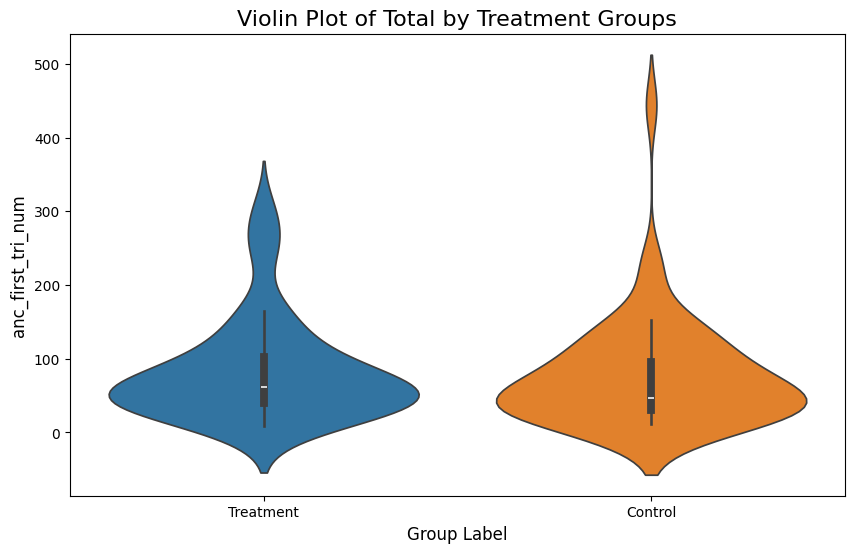

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the violin plot for Treatment and Control groups (using your 'Treatment' column)
plt.figure(figsize=(10, 6))
sns.violinplot(x="Group_Label", y="anc_first_tri_num", data=matched_pair_dedup, hue="Group_Label",
               order=["Treatment", "Control"], legend=False)

# Adding the titles and labels to the plot
plt.title('Violin Plot of Total by Treatment Groups', fontsize=16)
plt.xlabel('Group Label', fontsize=12)
plt.ylabel('anc_first_tri_num', fontsize=12)

# Displaying the plot
plt.show()

A new variable, Region, was created as a blocking factor based on the geographic location of districts. To categorize the data into two levels, districts were grouped as follows: North Region includes Serenje, Mkushi, Chitambo, Luano, Ngabwe, and Kapiri Mposhi; South Region includes Chibombo, Chisamba, Mumbwa, Itezhi-tezhi, and Kabwe.

In [ ]:
# Step 1: Define region mappings
north_districts = ['Serenje', 'Mkushi', 'Chitambo', 'Luano', 'Ngabwe', 'Kapiri Mposhi']
south_districts = ['Chibombo', 'Chisamba', 'Mumbwa', 'Itezhi-tezhi', 'Kabwe']

# Step 2: Define region assignment function
def assign_region(district):
    if district in north_districts:
        return 'North'
    elif district in south_districts:
        return 'South'
    else:
        return 'Unknown'

# Step 3: Create blocking_df from matched_pair_dedup
blocking_df = matched_pair_dedup.copy()

# Step 4: Add region column to blocking_df
blocking_df['region'] = blocking_df['d'].apply(assign_region)

blocking_df.head()

,treatment,facilitytype,pop_catchment,no_maternity_beds,distance_dmo,institutionaldeliveries,institutionaldeliverycoverage,stanccoverage1sttrimester,anc_first_tri_num,pair,fid,d,Group_Label,region
1092,1,Rural Health Centre,6968,2,153.0,10.0,32.3,12.8,40,3,51,Kapiri Mposhi,Treatment,North
83,0,Rural Health Centre,6900,2,150.0,13.0,49.2,65.2,76,3,8,Chibombo,Control,South
2695,1,Health Post - Rural,7421,2,25.0,10.0,29.8,11.8,89,4,118,Mumbwa,Treatment,South
1907,0,Rural Health Centre,7037,2,25.0,13.0,49.9,22.8,47,4,85,Serenje,Control,North
2376,1,Health Post - Rural,5852,1,189.0,6.0,23.0,26.6,35,5,105,Chisamba,Treatment,South


In [ ]:
# Get the unique levels for the blocking factor 'facilitytype_nhc'
blocking_factor_levels = blocking_df['region'].unique()
print(blocking_factor_levels)

['North' 'South']


**<mark>Section 3.4: Matched Pair Design Setup With Blocking Factor For Hypothesis 1</mark>** <br>

Blocking Factor: Region

Reason: The outcome variable (i.e. anc_first_tri_num) could be dependent on the geographic region that the womens are being placed in. We want to account for the variability within different region.
New matched pair criteria for the blocking factor setup: Facilities are paired based on having similar or closely aligned numbers of maternity beds.

In [ ]:
def match_pairs_within_region(region_df):
    # Separate treatment and control
    treatment_df = region_df[region_df['treatment'] == 1].copy()
    control_df = region_df[region_df['treatment'] == 0].copy()

    # Create empty dataframe to store matches
    matched_pairs = []

    # For each treatment unit, find the closest control unit based on no_maternity_beds
    for t_idx, t_row in treatment_df.iterrows():
        if len(control_df) == 0:
            break

        # Calculate absolute difference in no_maternity_beds for all control units
        control_df['distance'] = abs(control_df['no_maternity_beds'] - t_row['no_maternity_beds'])

        # Find the closest match
        closest_match_idx = control_df['distance'].idxmin()
        closest_match = control_df.loc[closest_match_idx].copy()

        # Add pair to results
        t_row_copy = t_row.copy()
        closest_match_copy = closest_match.copy()

        matched_pairs.append(t_row_copy)
        matched_pairs.append(closest_match_copy)

        # Remove the matched control unit to prevent reuse
        control_df = control_df.drop(closest_match_idx)

    # Convert list of Series to DataFrame
    if matched_pairs:
        matched_df = pd.DataFrame(matched_pairs)

        # Assign new pair numbers
        pair_ids = np.repeat(range(1, len(matched_df)//2 + 1), 2)
        matched_df['new_pair'] = pair_ids

        return matched_df
    else:
        return pd.DataFrame()  # Return empty dataframe if no matches found

# Step 1: Split dataset by region
north_df = blocking_df[blocking_df['region'] == 'North']
south_df = blocking_df[blocking_df['region'] == 'South']

# Step 2: Apply matching to both regions
north_matched = match_pairs_within_region(north_df)
south_matched = match_pairs_within_region(south_df)

# Step 3: Combine all matched pairs
final_matched_df = pd.concat([north_matched, south_matched], axis=0)

# Make sure 'new_pair' values are unique across regions
if not south_matched.empty:
    max_north_pair = north_matched['new_pair'].max() if not north_matched.empty else 0
    south_matched['new_pair'] = south_matched['new_pair'] + max_north_pair

# Step 4: Sort and reset index
final_matched_df = final_matched_df.sort_values(by=['region', 'new_pair', 'treatment']).reset_index(drop=True)

# Step 5: Preview result
final_matched_df[['region', 'new_pair', 'fid','treatment', 'no_maternity_beds', 'Group_Label', 'd', 'anc_first_tri_num']]

,region,new_pair,fid,treatment,no_maternity_beds,Group_Label,d,anc_first_tri_num
0,North,1,85,0,2,Control,Serenje,47
1,North,1,51,1,2,Treatment,Kapiri Mposhi,40
2,North,2,94,0,2,Control,Ngabwe,33
3,North,2,95,1,2,Treatment,Ngabwe,38
4,North,3,27,0,3,Control,Chitambo,28
...,...,...,...,...,...,...,...,...
89,South,20,40,1,3,Treatment,Kabwe,72
90,South,21,5,0,3,Control,Chibombo,24
91,South,21,98,1,1,Treatment,Chibombo,86
92,South,22,22,0,4,Control,Chisamba,48


Due to the slight imbalance in the values of the blocking factor, the number of newly assigned pairs is smaller than in the original setup.

In [ ]:
# Count pairs by region
north_pairs = final_matched_df[final_matched_df['region'] == 'North']['new_pair'].nunique()
south_pairs = final_matched_df[final_matched_df['region'] == 'South']['new_pair'].nunique()

# Get total number of pairs
total_pairs = north_pairs + south_pairs

# Print the counts
print(f"Number of pairs in North region: {north_pairs}")
print(f"Number of pairs in South region: {south_pairs}")
print(f"Total number of pairs: {total_pairs}")

Number of pairs in North region: 25
Number of pairs in South region: 22
Total number of pairs: 47


**Checking for Normality of Dependent Variable: anc_first_tri_num**

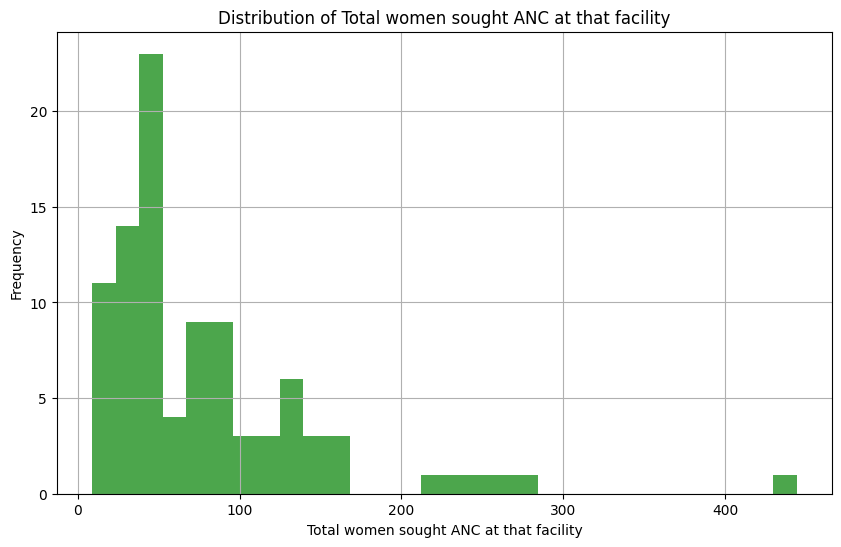

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram of the 'total' values in the selected sample
plt.figure(figsize=(10, 6))
plt.hist(final_matched_df['anc_first_tri_num'].dropna(), bins=30, color='green', alpha=0.7)

# Add title and axis labels
plt.title('Distribution of Total women sought ANC at that facility')
plt.xlabel('Total women sought ANC at that facility')
plt.ylabel('Frequency')

# Add a grid for readability
plt.grid(True)

# Show the plot
plt.show()

**Violin Plot to Display the Distribution after the Blocking & Randomization for Matched Pair Design**

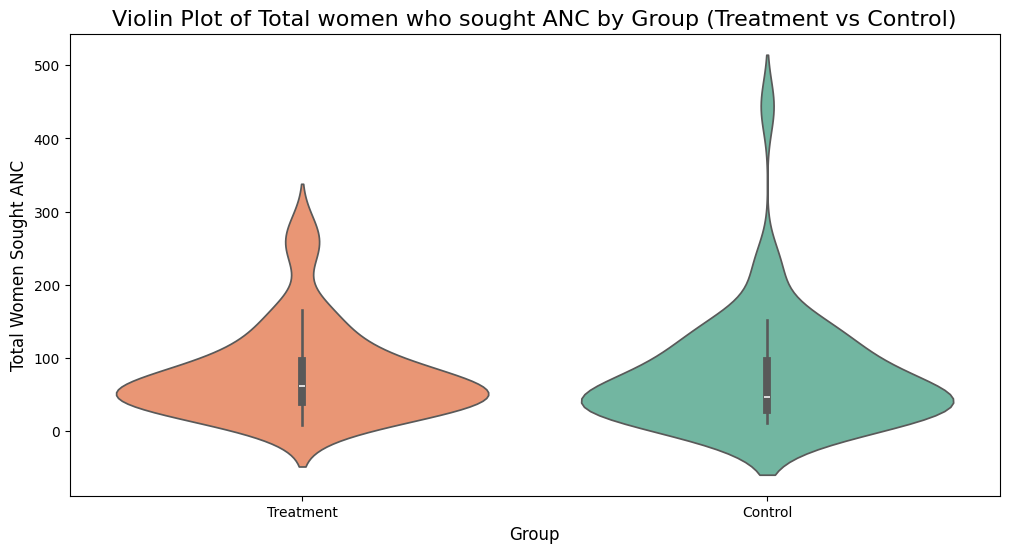

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Group_Label", y="anc_first_tri_num", data=final_matched_df, hue="Group_Label",
               order=["Treatment", "Control"], palette="Set2")

# Add title and labels
plt.title('Violin Plot of Total women who sought ANC by Group (Treatment vs Control)', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Total Women Sought ANC', fontsize=12)

# Show the plot
plt.show()

**Boxplot: A more clear visualization of the distribution after separating into different Regions and Incentive types (i.e. treatment/control groups)**

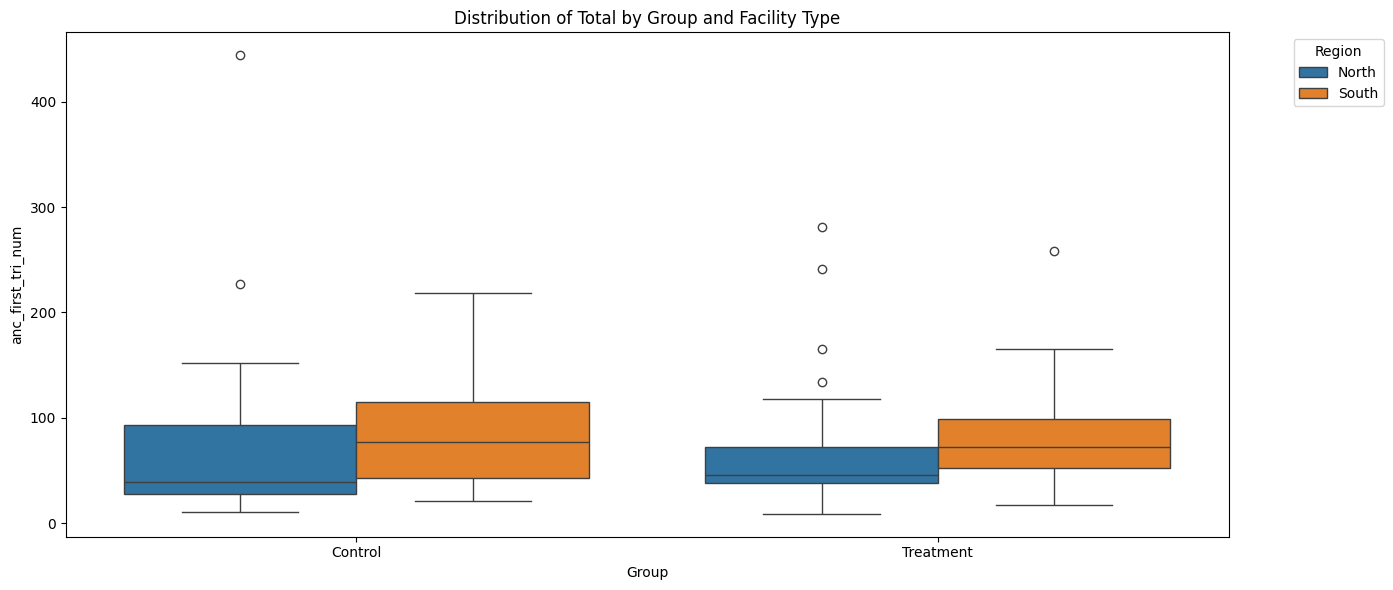

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values if any (optional safety step)
cleaned_df = final_matched_df.dropna(subset=['anc_first_tri_num', 'Group_Label', 'region'])

# Create the boxplot
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=cleaned_df, x="Group_Label", y="anc_first_tri_num", hue="region")

# Customize x-axis tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Treatment'], rotation=0)

# Customize the plot (labels, title, etc.)
ax.set_title('Distribution of Total by Group and Facility Type')
ax.set_xlabel('Group')
ax.set_ylabel('anc_first_tri_num')

# Add legend
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show plot
plt.show()

**TWO-WAY ANOVA & SUMMARY STATISTICS: After blocking using Region and match pairs using number of maternity beds and assign them into two groups (i.e. treatment/control) we use two-way ANOVA to find the significance of the blocking factor based on the p-value**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Example formula using variables from your dataset
formula = 'anc_first_tri_num ~ Group_Label + region + Group_Label:region'

# Fit the model
model_matched_b = ols(formula, data=final_matched_df).fit()

# Perform ANOVA and print table
aov_table = sm.stats.anova_lm(model)
print(aov_table)

# Print the model summary
print(model_matched_b.summary())

                       df      sum_sq    mean_sq          F    PR(>F)
Group_Label           1.0    1.541096   1.541096   0.794805  0.374159
region                1.0   30.790083  30.790083  15.879674  0.000107
Group_Label:region    1.0    9.274595   9.274595   4.783279  0.030374
Residual            142.0  275.332583   1.938962        NaN       NaN
                            OLS Regression Results                            
Dep. Variable:      anc_first_tri_num   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.027
Method:                 Least Squares   F-statistic:                    0.1710
Date:                Mon, 14 Apr 2025   Prob (F-statistic):              0.916
Time:                        23:46:28   Log-Likelihood:                -530.23
No. Observations:                  94   AIC:                             1068.
Df Residuals:                      90   BIC:                             1079.
Df Model:         

**TUKEY'S HSD TEST: Post-hoc analysis following Two-Way ANOVA**

> SOURCE: https://campus.datacamp.com/courses/experimental-design-in-python/analyzing-experimental-data-statistical-tests-and-power?ex=5

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey's HSD test for Group_Label
tukey_group = pairwise_tukeyhsd(endog=final_matched_df['anc_first_tri_num'], groups=final_matched_df['Group_Label'], alpha=0.05)

print("\nTukey HSD Test Results for Group_Label (Treatment vs Control):")
print(tukey_group)


Tukey HSD Test Results for Group_Label (Treatment vs Control):
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
Control Treatment   2.0426 0.8863 -26.2587 30.3438  False
---------------------------------------------------------


**Checking Assumptions for Two-Way ANOVA:**

> 1. IID: Independently & Identically distributed taken care of by random sampling.
2. Normality: Testing for normality of residuals after fitting the model using the Shapiro-Wilk test
3. Homoscedasticity: variances of the dependent variable should be approximately equal across the different groups using

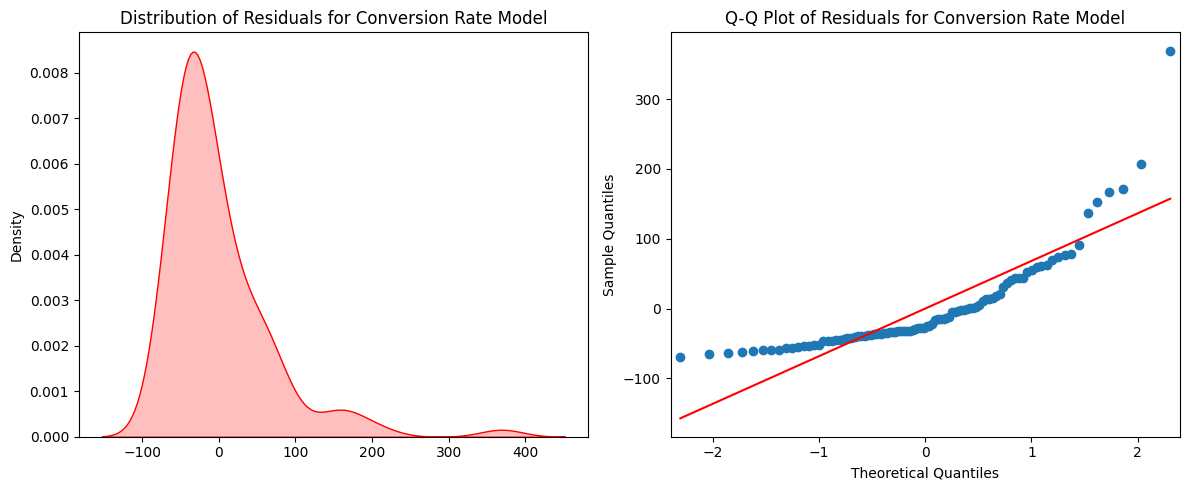

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get residuals after fitting the model
residuals_matched_b = model_matched_b.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residuals_matched_b, ax=ax[0], color='red', fill=True)
ax[0].set_title('Distribution of Residuals for Conversion Rate Model')

# Q-Q plot
sm.qqplot(residuals_matched_b, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals for Conversion Rate Model')

# Plotting the graphs
plt.tight_layout()
plt.show()

**Performing Shapiro-Wilk test on residuals after fitting the model to check for assumption of normality.**

In [ ]:
from scipy import stats

# Perform Shapiro-Wilk test on residuals
shapiro_res = stats.shapiro(residuals_matched_b.dropna())

print(f'W: {round(shapiro_res[0], 3)}, P-value: {round(shapiro_res[1], 3)}')

W: 0.758, P-value: 0.0


**<mark>3.5 Matched Pair Design Setup With Continuous Covariates For Hypothesis 1:</mark>** <br>
> **Covariate Used:** `distance_dmo` </br>

> **Subset Requirement:** We add the new continuous covariate variable distance_dmo, and the basic matched pair setup is using number of maternity beds number as the criteria.

> **GLM Requirements:** We removed `region` (used previously as a blocking factor) to isolate the effect of these numeric covariates in a GLM framework. The chosen covariate account for variability in distance to district medical office. It is expected to influence how the incentives help increase total women who sought ANC at that facility over the entire period.

In [ ]:
import pandas as pd
import numpy as np

def match_pairs(df):
    # Separate treatment and control
    treatment_df = df[df['treatment'] == 1].copy()
    control_df = df[df['treatment'] == 0].copy()

    # Create empty list to store matches
    matched_pairs = []

    # For each treatment unit, find the closest control unit based on no_maternity_beds
    for t_idx, t_row in treatment_df.iterrows():
        if len(control_df) == 0:
            break

        # Calculate absolute difference in no_maternity_beds for all control units
        control_df['distance'] = abs(control_df['no_maternity_beds'] - t_row['no_maternity_beds'])

        # Find the closest match
        closest_match_idx = control_df['distance'].idxmin()
        closest_match = control_df.loc[closest_match_idx].copy()

        # Add pair to results
        t_row_copy = t_row.copy()
        closest_match_copy = closest_match.copy()

        matched_pairs.append(t_row_copy)
        matched_pairs.append(closest_match_copy)

        # Remove the matched control unit to prevent reuse
        control_df = control_df.drop(closest_match_idx)

    # Convert list of Series to DataFrame
    if matched_pairs:
        matched_df = pd.DataFrame(matched_pairs)

        # Assign new pair numbers
        pair_ids = np.repeat(range(1, len(matched_df)//2 + 1), 2)
        matched_df['new_pair'] = pair_ids

        return matched_df
    else:
        return pd.DataFrame()  # Return empty dataframe if no matches found

# Apply matching to entire dataset without blocking by region
match_co_df = match_pairs(blocking_df)

# Sort and reset index
match_co_df = match_co_df.sort_values(by=['new_pair', 'treatment']).reset_index(drop=True)

# Count pairs
num_pairs = match_co_df['new_pair'].nunique()
print(f"Total number of pairs: {num_pairs}")

# Preview result
match_co_df[['fid', 'new_pair', 'treatment', 'distance_dmo','no_maternity_beds', 'Group_Label', 'd', 'anc_first_tri_num']]

match_co_df.head()

Total number of pairs: 49


,treatment,facilitytype,pop_catchment,no_maternity_beds,distance_dmo,institutionaldeliveries,institutionaldeliverycoverage,stanccoverage1sttrimester,anc_first_tri_num,pair,fid,d,Group_Label,region,distance,new_pair
0,0,Rural Health Centre,6900,2,150.0,13.0,49.2,65.2,76,3,8,Chibombo,Control,South,0.0,1
1,1,Rural Health Centre,6968,2,153.0,10.0,32.3,12.8,40,3,51,Kapiri Mposhi,Treatment,North,NaN,1
2,0,Rural Health Centre,7037,2,25.0,13.0,49.9,22.8,47,4,85,Serenje,Control,North,0.0,2
3,1,Health Post - Rural,7421,2,25.0,10.0,29.8,11.8,89,4,118,Mumbwa,Treatment,South,NaN,2
4,0,Rural Health Centre,6141,1,192.0,12.0,7.2,7.1,37,5,53,Kapiri Mposhi,Control,North,0.0,3


**SOURCE FOR ANCOVA CODE:** https://www.reneshbedre.com/blog/ancova.html

In [ ]:
# Run GLM with covariates (no blocking factor)
model2_cov = ols('anc_first_tri_num ~ C(Group_Label) + distance_dmo', data = match_co_df).fit()
anova_cov2 = sm.stats.anova_lm(model2_cov, typ=2)

# Perform the Type III ANOVA and display the results
# Use typ=3 for Type III SS: used in ANCOVA because it tests the main effects and interactions, adjusting for the presence of other factors
aov_table = sm.stats.anova_lm(model2_cov, typ=3)
print(aov_table)
print(model2_cov.summary())

                       sum_sq    df          F        PR(>F)
Intercept       186788.948944   1.0  36.483300  2.984449e-08
C(Group_Label)     756.040132   1.0   0.147668  7.016323e-01
distance_dmo      6614.889073   1.0   1.292009  2.585372e-01
Residual        486385.559906  95.0        NaN           NaN
                            OLS Regression Results                            
Dep. Variable:      anc_first_tri_num   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.7134
Date:                Mon, 14 Apr 2025   Prob (F-statistic):              0.493
Time:                        23:20:14   Log-Likelihood:                -556.04
No. Observations:                  98   AIC:                             1118.
Df Residuals:                      95   BIC:                             1126.
Df Model:                           2                          

**Checking Assumptions for ANCOVA:**

> 1. IID: Independently & Identically distributed taken care of by random sampling.
2. Normality: Testing for normality of residuals after fitting the model using the Shapiro-Wilk test
3. Homoscedasticity: variances of the dependent variable should be approximately equal across the different groups using

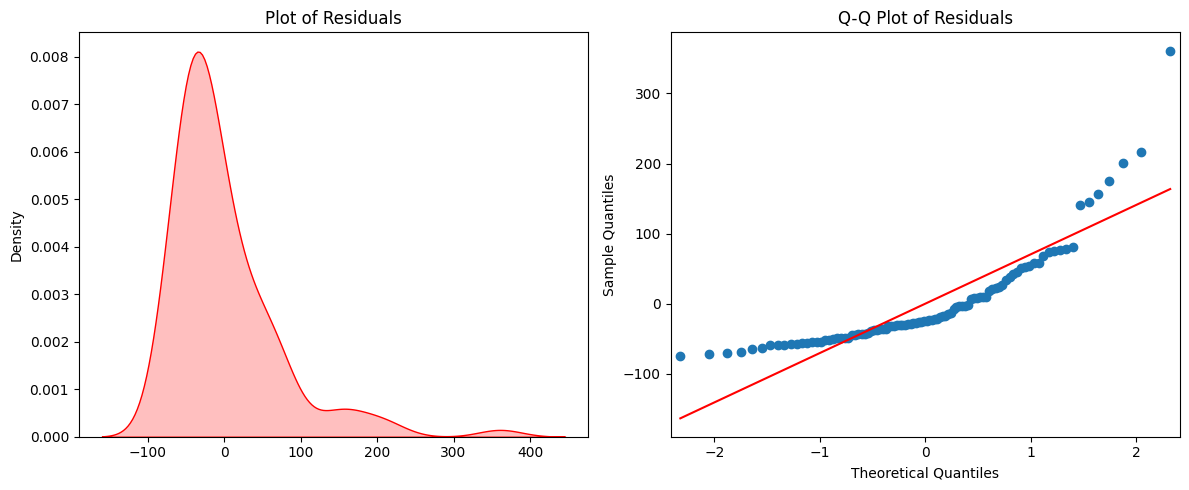

In [ ]:
import seaborn as sns
import statsmodels.api as sm

# Get residuals after fitting the model
residual_cov2 = model2_cov.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill instead of shade
sns.kdeplot(residual_cov2, ax=ax[0], color='red', fill=True)
ax[0].set_title('Plot of Residuals')

# Q-Q plot
sm.qqplot(residual_cov2, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')

# Plotting the graphs below
plt.tight_layout()
plt.show()

In [ ]:
# Perform Shapiro-Wilk test on residuals
shapiro_resid = stats.shapiro(residual_cov2.dropna())

print(f'W: {round(shapiro_resid[0], 3)}, P-value: {round(shapiro_resid[1], 3)}')

W: 0.776, P-value: 0.0


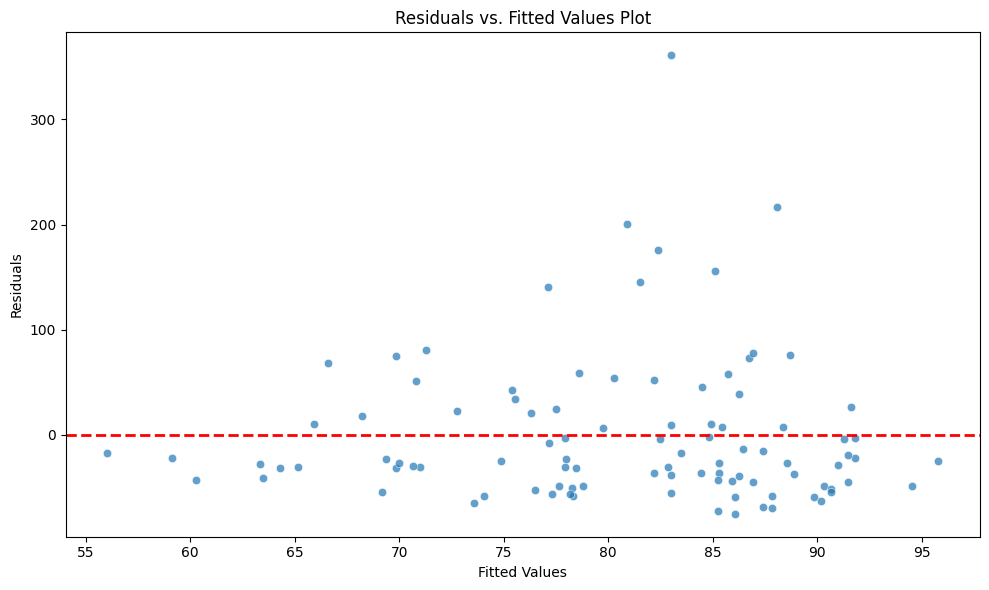

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Get the residuals and the fitted values
residual_cov2 = model2_cov.resid
fitted_value = model2_cov.fittedvalues

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_value, y=residual_cov2, alpha=0.7)
# Line at zero as a reference
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Residuals vs. Fitted Values Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# **3.6 Matched Pair Design: Hypothesis 2**

  | H0: The intervention/treatment (incentives for CBVs) will lead to an increase in the total number of women referred by CBVs(Community-Based Volunteers). <br>
  | HA: The intervention/treatment (incentives for CBVs) will NOT lead to an increase total number of women referred by CBVs(Community-Based Volunteers). <br>

Notes From Report 1: The incentive/treatment was monetary aid given to NHCs() for either referring or escorting women to seek ANC(Antenatal Care) within the first trimester(14 weeks). In the control health facilities, the status quo is maintained where CBVs support health service delivery on a voluntary basis with no monetary benefits. In the treatment health facilities,the CBVs are provided with monetary incentives.<br>

**Variables Used for Matched Pair Design Hypothesis 2:** <br>

Independent Variables: treatment_nhc <br>
  - This variable indicates whether the facility received an intervention involving monetary incentives for the CBVs (treatment group) or not (control group). <br>
  - 1 represents the treatment group (i.e., facilities where Community-Based Volunteers (CBVs) receive incentives).
  - 0 represents the control group (i.e., facilities where CBVs do not receive incentives, and they continue to work on a voluntary basis).

Dependent Variable: Referred <br>
  - This represents the total number of women who were referred by CBVs to seek ANC during the first trimester. <br>

Matching Variable: pop_total<br>
- This represents the total population in nhc catchment zone <br>

**<mark>Section 3.7: Power Analysis, Sample Size, & Associated Graph</mark>** </br>
>Effect Size: Medium (0.5)</br>
Power: 0.85 <br>
Total Sample Size: 146 </br>

In [ ]:
from statsmodels.stats.power import TTestIndPower

# Power Analysis for Parallel Design Scenario

# Medium effect size
effect_size = 0.5
# Significance level
alpha = 0.05
# Power value
power = 0.85
# parallel design
number_groups = 2

# Current dataset size: total rows in your dataset
dataset_size = len(merged_df)
current_sample_size = dataset_size

# Creating a power analysis object
analysis = TTestIndPower()

# Calculating the required sample size per group
result = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)

# Rounding to get integer sample size
required_sample_size_per_group = round(result)

# Total sample size required for the experiment
total_sample_size = required_sample_size_per_group * number_groups

# Output the result
print(f'Required sample size per group: {required_sample_size_per_group}')
print(f'Total sample size for all groups: {total_sample_size}')

Required sample size per group: 73
Total sample size for all groups: 146


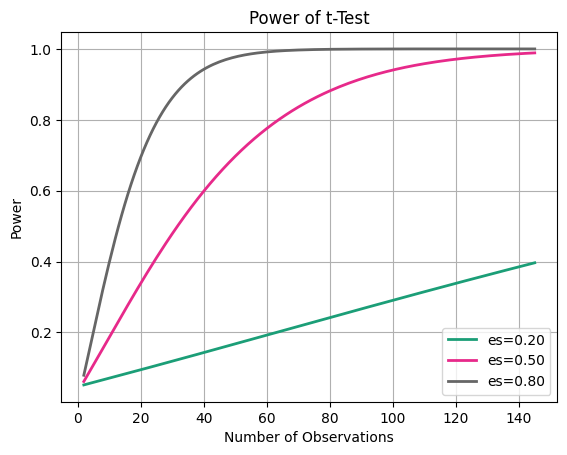

In [ ]:
from numpy import array
from matplotlib import pyplot

# Effect sizes: small (0.2), medium (0.5), large (0.8)
effect_sizes = array([0.2, 0.5, 0.8])

# Sample sizes: range from 2 to 146
sample_sizes = array(range(2, 146))

# Create a power analysis object for t-tests
analysis = TTestIndPower()

# Plot power curves
analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes, alpha=0.05, title='Power of t-Test')

# Formatting the plot
pyplot.grid()
pyplot.ylabel('Power')
pyplot.show()

**<mark>Section 3.8: Matched Pair Design Setup For Hypothesis 2</mark>** <br>

  1. Creating the required subset for matched pair design on hypothesis 2. Participants are randomly assigned to either the treatment or control group. They remain in their assigned group throughout the study.To achieve medium effect, a total of 146 participants are selected from dataset. <br>
  
  2. The population size within the NHC catchment zone was used as the matching variable to ensure that each pair had a similar population, helping to mitigate variance in catchment population size when assigning treatment. <br>

  3. Splitting the participants into either treatment or control. Random participants will be selected from the original dataset such that: <br>
    - Group 1 (Treatment - Incentives, 73 participants)
    - Group 1 (Control - No Incentives, 73 participants)

In [ ]:
# Setting the seed for reproducibility
np.random.seed(42)

# Create a copy of the merged dataframe with relevant columns
matched_pair_df = merged_df[["treatment_nhc", "pop_total", "referred", "fid", "d"]].copy()

# Create group labels based on treatment_nhc
matched_pair_df['Group_Label'] = matched_pair_df['treatment_nhc'].apply(lambda x: 'Treatment' if x == 1 else 'Control')

# Split into Treatment and Control groups
treatment_df = matched_pair_df[matched_pair_df['Group_Label'] == 'Treatment']
control_df = matched_pair_df[matched_pair_df['Group_Label'] == 'Control']

# Sort both dataframes by pop_total to prepare for matching
treatment_df = treatment_df.sort_values('pop_total').reset_index(drop=True)
control_df = control_df.sort_values('pop_total').reset_index(drop=True)

# Make sure we have enough data in both groups
min_size = min(len(treatment_df), len(control_df))
if min_size < 73:
    print(f"Warning: Only {min_size} matches possible (need 73)")

# Create pairs based on similar pop_total values
# Take min(available pairs, 73) pairs
pairs_to_create = min(min_size, 73)

# Create a list to store matched pairs
matched_pairs = []

# Match treatment and control facilities with similar pop_total values
for i in range(pairs_to_create):
    # Add pair identifier
    treatment_row = treatment_df.iloc[i].copy()
    control_row = control_df.iloc[i].copy()

    treatment_row['pair_id'] = i + 1
    control_row['pair_id'] = i + 1

    matched_pairs.append(treatment_row)
    matched_pairs.append(control_row)

# Create final matched pair dataset with the new name
matched_h2_df = pd.DataFrame(matched_pairs)

# Verify equal distribution
print("Distribution of treatment vs control groups:")
print(matched_h2_df['Group_Label'].value_counts())
print("\nTotal number of pairs:", pairs_to_create)

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Display the matched pairs dataset
matched_h2_df.head()

Distribution of treatment vs control groups:
Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

Total number of pairs: 73

----------------------------------------------------------------------



,treatment_nhc,pop_total,referred,fid,d,Group_Label,pair_id
0,1,10.0,7.0,98,Chibombo,Treatment,1
0,0,103.0,1.0,58,Luano,Control,1
1,1,10.0,5.0,98,Chibombo,Treatment,2
1,0,108.0,4.0,107,Chisamba,Control,2
2,1,10.0,7.0,98,Chibombo,Treatment,3


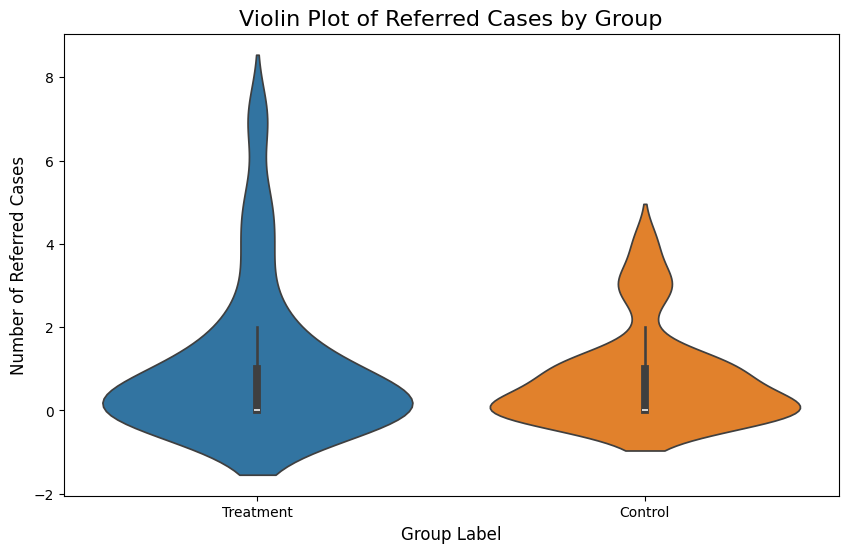

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the violin plot for Treatment and Control groups using 'referred'
plt.figure(figsize=(10, 6))
sns.violinplot(x="Group_Label", y="referred", data=matched_h2_df, hue="Group_Label",
               order=["Treatment", "Control"], legend=False)

# Adding the titles and labels to the plot
plt.title('Violin Plot of Referred Cases by Group', fontsize=16)
plt.xlabel('Group Label', fontsize=12)
plt.ylabel('Number of Referred Cases', fontsize=12)

# Displaying the plot
plt.show()

A new variable, Region, was created as a blocking factor based on the geographic location of districts. To categorize the data into two levels, districts were grouped as follows: North Region includes Serenje, Mkushi, Chitambo, Luano, Ngabwe, and Kapiri Mposhi; South Region includes Chibombo, Chisamba, Mumbwa, Itezhi-tezhi, and Kabwe.

In [ ]:

# Step 1: Define region mappings
north_districts = ['Serenje', 'Mkushi', 'Chitambo', 'Luano', 'Ngabwe', 'Kapiri Mposhi']
south_districts = ['Chibombo', 'Chisamba', 'Mumbwa', 'Itezhi-tezhi', 'Kabwe']

# Step 2: Define region assignment function
def assign_region(district):
    if district in north_districts:
        return 'North'
    elif district in south_districts:
        return 'South'
    else:
        return 'Unknown'

# Step 3: Create blocking_h2_df from merged_df
blocking_h2_df = merged_df.copy()

# Step 4: Add region column based on district info in 'd'
blocking_h2_df['region'] = blocking_h2_df['d'].apply(assign_region)

# Preview result
blocking_h2_df.head()


,treatment_nhc,femalenhc_ratio,femalesmag_ratio,pop_total,referred,accompanied,total,facilitytype_nhc,pair_nhc,month,...,no_maternity_beds,distance_dmo,institutionaldeliveries,institutionaldeliverycoverage,stanccoverage1sttrimester,anc_first_tri_num,pair_fac,yr_month,d,region
0,0,0.375000,0.4,647.0,3.0,0.0,3.0,Rural Health Centre,91,1,...,3,45.0,35.0,70.5,63.9,444,29,201801,Serenje,North
1,0,0.375000,0.4,647.0,3.0,0.0,3.0,Rural Health Centre,91,1,...,3,45.0,38.0,42.6,57.8,444,29,201901,Serenje,North
2,0,0.375000,0.4,647.0,3.0,0.0,3.0,Rural Health Centre,91,1,...,3,45.0,45.0,86.2,87.2,444,29,202001,Serenje,North
3,0,0.428571,0.6,2096.0,13.0,0.0,13.0,Rural Health Centre,91,1,...,3,45.0,35.0,70.5,63.9,444,29,201801,Serenje,North
4,0,0.428571,0.6,2096.0,13.0,0.0,13.0,Rural Health Centre,91,1,...,3,45.0,38.0,42.6,57.8,444,29,201901,Serenje,North


**<mark>Section 3.9: Matched Pair Design Setup With Blocking Factor For Hypothesis 2</mark>** <br>

Blocking Factor: region

Reason: The outcome variable (i.e. referred) could be dependent on the geographic region that the womens are being placed in. We want to account for the variability within different region.

In [ ]:
# Step 2: Define function to match pairs within region
def match_within_region(region_df, n_pairs):
    df = region_df[["treatment_nhc", "pop_total", "referred", "fid", "d", "region"]].copy()
    df['Group_Label'] = df['treatment_nhc'].apply(lambda x: 'Treatment' if x == 1 else 'Control')

    treatment_df = df[df['Group_Label'] == 'Treatment'].sort_values('pop_total').reset_index(drop=True)
    control_df = df[df['Group_Label'] == 'Control'].sort_values('pop_total').reset_index(drop=True)

    min_size = min(len(treatment_df), len(control_df), n_pairs)
    matched_pairs = []
    used_control_idx = set()

    for i in range(min_size):
        t_row = treatment_df.iloc[i].copy()

        # Find closest control
        available_controls = control_df.loc[~control_df.index.isin(used_control_idx)]
        if available_controls.empty:
            break
        diffs = (available_controls['pop_total'] - t_row['pop_total']).abs()
        closest_idx = diffs.idxmin()
        c_row = control_df.loc[closest_idx].copy()

        t_row['pair_id'] = i + 1
        c_row['pair_id'] = i + 1

        matched_pairs.extend([t_row, c_row])
        used_control_idx.add(closest_idx)

    return pd.DataFrame(matched_pairs)

# Step 3: Split by region and match
north_df = blocking_h2_df[blocking_h2_df['region'] == 'North']
south_df = blocking_h2_df[blocking_h2_df['region'] == 'South']

north_matched = match_within_region(north_df, 36)
south_matched = match_within_region(south_df, 37)

# Step 4: Combine results and adjust pair IDs to be unique
south_matched['pair_id'] += 36  # shift South IDs to start from 37

# Final output: blocking_m_h2_df
blocking_m_h2_df = pd.concat([north_matched, south_matched], ignore_index=True)

# Step 5: Show summary
print("Distribution of treatment vs control groups:")
print(blocking_m_h2_df['Group_Label'].value_counts())
print("\nTotal number of pairs:", blocking_m_h2_df['pair_id'].nunique())
print("\n" + "-"*70 + "\n")

# Preview
blocking_m_h2_df.head()

Distribution of treatment vs control groups:
Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

Total number of pairs: 73

----------------------------------------------------------------------



,treatment_nhc,pop_total,referred,fid,d,region,Group_Label,pair_id
0,1,83.0,1.0,95,Ngabwe,North,Treatment,1
1,0,103.0,1.0,58,Luano,North,Control,1
2,1,83.0,1.0,95,Ngabwe,North,Treatment,2
3,0,167.0,0.0,94,Ngabwe,North,Control,2
4,1,83.0,1.0,95,Ngabwe,North,Treatment,3


**Checking for Normality of Dependent Variable: Referred**

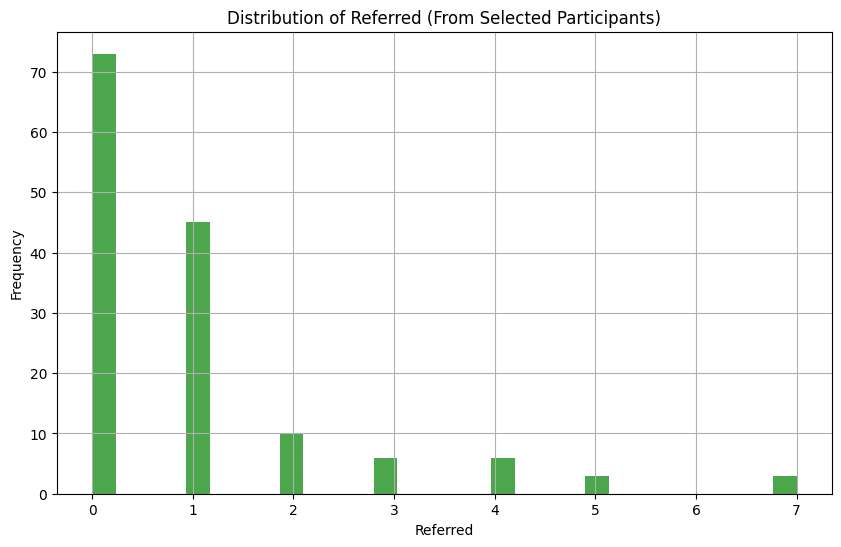

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram of the 'referred' values in the selected sample
plt.figure(figsize=(10, 6))
plt.hist(blocking_m_h2_df['referred'].dropna(), bins=30, color='green', alpha=0.7)

# Add title and axis labels
plt.title('Distribution of Referred (From Selected Participants)')
plt.xlabel('Referred')
plt.ylabel('Frequency')

# Add a grid for readability
plt.grid(True)

# Show the plot
plt.show()


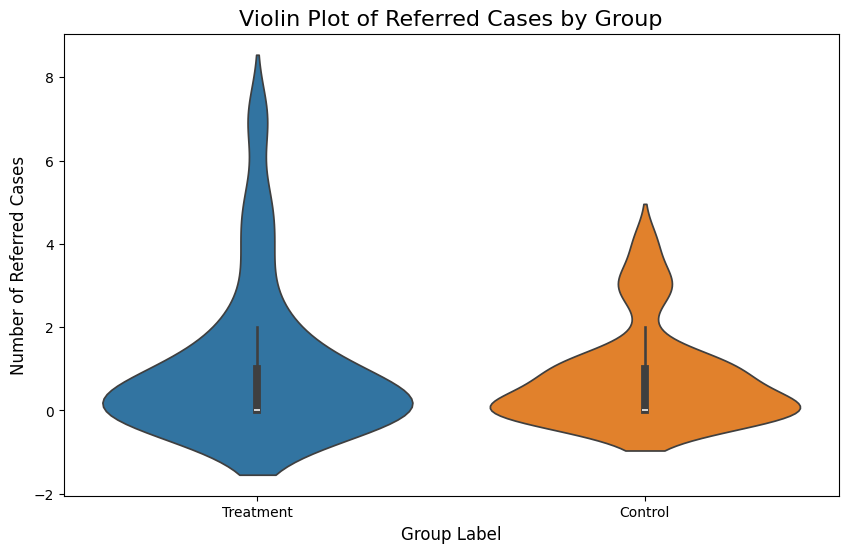

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the violin plot for Treatment and Control groups using 'referred'
plt.figure(figsize=(10, 6))
sns.violinplot(x="Group_Label", y="referred", data=matched_h2_df, hue="Group_Label",
               order=["Treatment", "Control"], legend=False)

# Adding the titles and labels to the plot
plt.title('Violin Plot of Referred Cases by Group', fontsize=16)
plt.xlabel('Group Label', fontsize=12)
plt.ylabel('Number of Referred Cases', fontsize=12)

# Displaying the plot
plt.show()

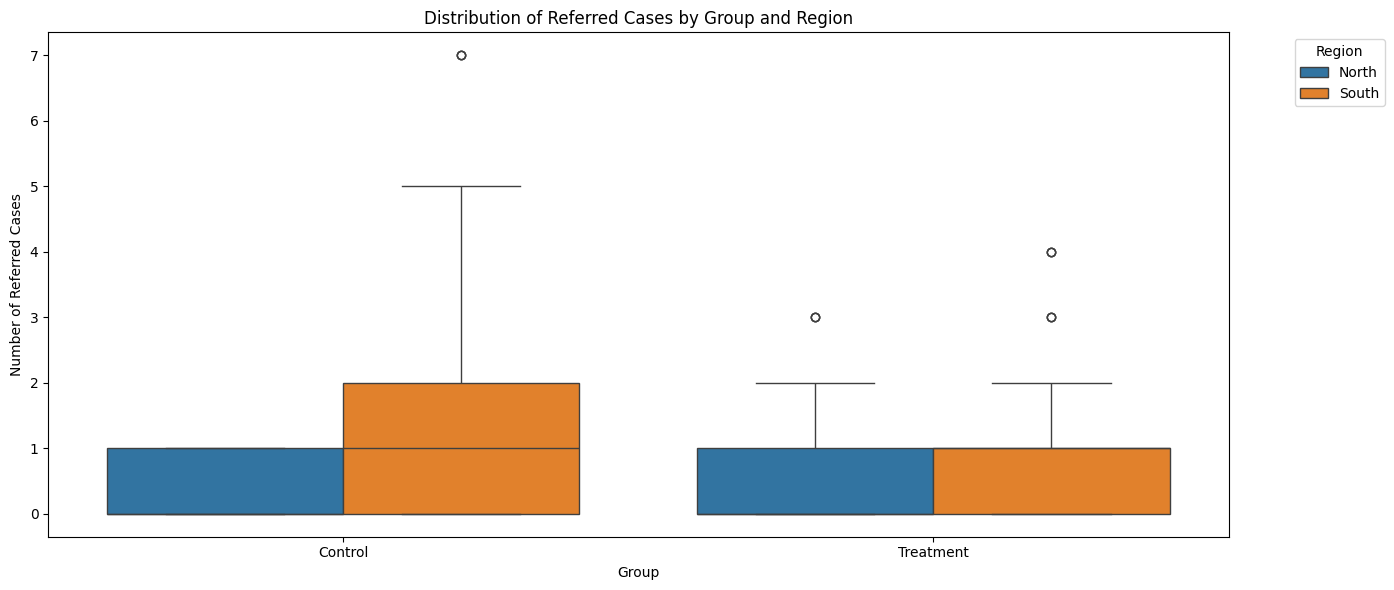

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values for relevant columns
cleaned_df = blocking_m_h2_df.dropna(subset=['referred', 'Group_Label', 'region'])

# Create the boxplot
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=cleaned_df, x="Group_Label", y="referred", hue="region")

# Customize x-axis tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Treatment'], rotation=0)

# Customize the plot
ax.set_title('Distribution of Referred Cases by Group and Region')
ax.set_xlabel('Group')
ax.set_ylabel('Number of Referred Cases')

# Add legend
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


>**TWO-WAY ANOVA & SUMMARY STATISTICS: After applying a blocking strategy using region and matching catchment zones with similar population sizes, facilities were randomly assigned to treatment and control groups. A two-way ANOVA was then conducted to evaluate the statistical significance of the blocking factor, with the p-value indicating whether regional differences had a meaningful impact on the outcome.**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define the ANOVA formula based on your new variables
formula = 'referred ~ Group_Label + region + Group_Label:region'

# Fit the model
model = ols(formula, data=blocking_m_h2_df).fit()

# Perform the two-way ANOVA
aov_table = sm.stats.anova_lm(model)
print("Two-Way ANOVA Table:\n")
print(aov_table)

# Print model summary
print("\nModel Summary:\n")
print(model.summary())


Two-Way ANOVA Table:

                       df      sum_sq    mean_sq          F    PR(>F)
Group_Label           1.0    1.541096   1.541096   0.794805  0.374159
region                1.0   30.790083  30.790083  15.879674  0.000107
Group_Label:region    1.0    9.274595   9.274595   4.783279  0.030374
Residual            142.0  275.332583   1.938962        NaN       NaN

Model Summary:

                            OLS Regression Results                            
Dep. Variable:               referred   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     7.153
Date:                Tue, 15 Apr 2025   Prob (F-statistic):           0.000166
Time:                        00:15:36   Log-Likelihood:                -253.47
No. Observations:                 146   AIC:                             514.9
Df Residuals:                     142   BIC:              

**TUKEY'S HSD TEST: Post-hoc analysis following Two-Way ANOVA Before Log-Transformation**

> SOURCE: https://campus.datacamp.com/courses/experimental-design-in-python/analyzing-experimental-data-statistical-tests-and-power?ex=5

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey's HSD test for Group_Label on 'referred'
tukey_result = pairwise_tukeyhsd(
    endog=blocking_m_h2_df['referred'],
    groups=blocking_m_h2_df['Group_Label'],
    alpha=0.05
)

# Display results
print("\nTukey HSD Test Results for Group_Label (Treatment vs Control):")
print(tukey_result)



Tukey HSD Test Results for Group_Label (Treatment vs Control):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower  upper  reject
------------------------------------------------------
Control Treatment   0.2055 0.403 -0.2787 0.6897  False
------------------------------------------------------


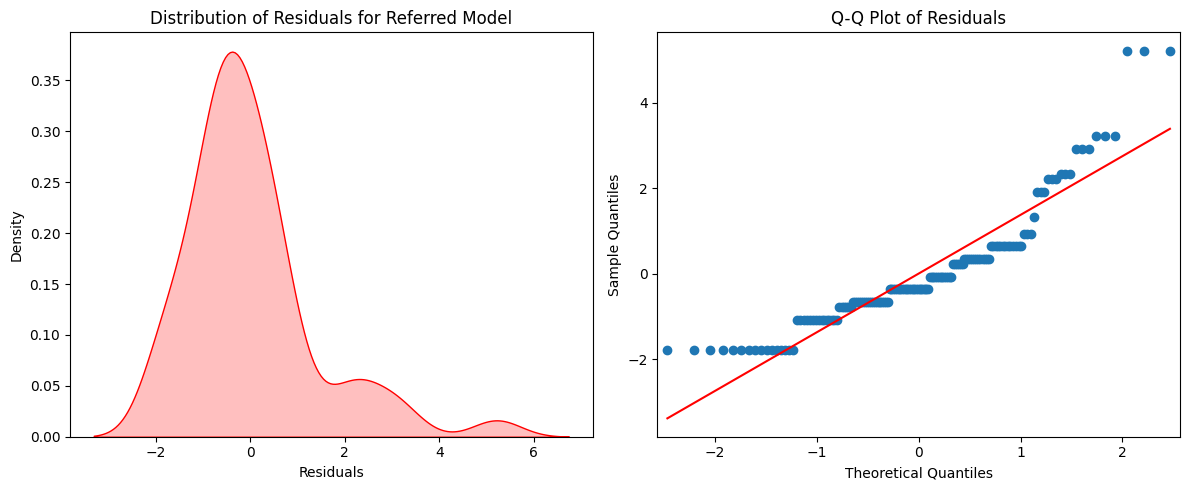

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get residuals from the fitted model on referred ~ Group_Label * region
residuals = model.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill
sns.kdeplot(residuals, ax=ax[0], color='red', fill=True)
ax[0].set_title('Distribution of Residuals for Referred Model')
ax[0].set_xlabel('Residuals')

# Q-Q plot to check normality
sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals')

# Final layout
plt.tight_layout()
plt.show()


In [ ]:
from scipy import stats

# Perform Shapiro-Wilk test on model residuals
shapiro_test = stats.shapiro(residuals.dropna())

# Output results
print("Shapiro-Wilk Test for Normality of Residuals:")
print(f"W-statistic: {round(shapiro_test.statistic, 3)}, P-value: {round(shapiro_test.pvalue, 3)}")


Shapiro-Wilk Test for Normality of Residuals:
W-statistic: 0.86, P-value: 0.0


**<mark>Section 3.10: Matched Pair Design Setup With Continuous Covariates (exluding blocking factor) For Hypothesis 2</mark>** <br>
> **Covariate Used:** `femalesmag_ratio` </br>

> **Subset Requirement:** We add the new continuous covariate variable into our subset but use the matched pair design from the original setup.

> **GLM Requirements:** We removed `region` (used previously as a blocking factor) to isolate the effect of these numeric covariates in a GLM framework. The chosen covariate account for variability in referral behavior due to population size and gender dynamics in the Safe Motherhood Action Group. It is expected to influence how the incentives help increase number of referrals.

In [ ]:
# Setting the seed for reproducibility
np.random.seed(42)

# Create a copy of the merged dataframe with relevant columns
matched_pair_df = merged_df[["treatment_nhc", "pop_total", "referred", "femalesmag_ratio", "fid", "d"]].copy()

# Create group labels based on treatment_nhc
matched_pair_df['Group_Label'] = matched_pair_df['treatment_nhc'].apply(lambda x: 'Treatment' if x == 1 else 'Control')

# Split into Treatment and Control groups
treatment_df = matched_pair_df[matched_pair_df['Group_Label'] == 'Treatment']
control_df = matched_pair_df[matched_pair_df['Group_Label'] == 'Control']

# Sort both dataframes by pop_total to prepare for matching
treatment_df = treatment_df.sort_values('pop_total').reset_index(drop=True)
control_df = control_df.sort_values('pop_total').reset_index(drop=True)

# Make sure we have enough data in both groups
min_size = min(len(treatment_df), len(control_df))
if min_size < 73:
    print(f"Warning: Only {min_size} matches possible (need 73)")

# Create pairs based on similar pop_total values
pairs_to_create = min(min_size, 73)

# Create a list to store matched pairs
matched_pairs = []

# Match treatment and control facilities with similar pop_total values
for i in range(pairs_to_create):
    # Add pair identifier
    treatment_row = treatment_df.iloc[i].copy()
    control_row = control_df.iloc[i].copy()

    treatment_row['pair_id'] = i + 1
    control_row['pair_id'] = i + 1

    matched_pairs.append(treatment_row)
    matched_pairs.append(control_row)

# Create final matched pair dataset with the new name
matched_co_h2_df = pd.DataFrame(matched_pairs)

# Verify equal distribution
print("Distribution of treatment vs control groups:")
print(matched_co_h2_df['Group_Label'].value_counts())
print("\nTotal number of pairs:", pairs_to_create)

# Add a space between the outputs for visual clarity
print("\n" + "-"*70 + "\n")

# Display the matched pairs dataset
matched_co_h2_df.head()


Distribution of treatment vs control groups:
Group_Label
Treatment    73
Control      73
Name: count, dtype: int64

Total number of pairs: 73

----------------------------------------------------------------------



,treatment_nhc,pop_total,referred,femalesmag_ratio,fid,d,Group_Label,pair_id
0,1,10.0,7.0,0.666667,98,Chibombo,Treatment,1
0,0,103.0,1.0,0.000000,58,Luano,Control,1
1,1,10.0,5.0,0.666667,98,Chibombo,Treatment,2
1,0,108.0,4.0,0.769231,107,Chisamba,Control,2
2,1,10.0,7.0,0.666667,98,Chibombo,Treatment,3


>**SOURCE FOR ANCOVA CODE:** https://www.reneshbedre.com/blog/ancova.html

Note: This is using the dependent variable without log transformation.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define the ANCOVA formula using matched_co_h2_df
formula_m_cov2 = 'referred ~ C(treatment_nhc) + femalesmag_ratio + C(treatment_nhc):femalesmag_ratio'

# Fit the model and assign to model_m_cov2
model_m_cov2 = ols(formula_m_cov2, data=matched_co_h2_df).fit()

# Run Type III ANOVA
aov_table_m_cov2 = sm.stats.anova_lm(model_m_cov2, typ=3)

# Print the ANOVA table
print("Type III ANOVA Table (model_m_cov2):")
print(aov_table_m_cov2)

# Print model summary
print("\nModel Summary (model_m_cov2):")
print(model_m_cov2.summary())



Type III ANOVA Table (model_m_cov2):
                                       sum_sq     df         F    PR(>F)
Intercept                            3.582945    1.0  1.625408  0.204421
C(treatment_nhc)                    16.768879    1.0  7.607228  0.006579
femalesmag_ratio                    17.293586    1.0  7.845262  0.005806
C(treatment_nhc):femalesmag_ratio   13.563867    1.0  6.153269  0.014285
Residual                           313.015574  142.0       NaN       NaN

Model Summary (model_m_cov2):
                            OLS Regression Results                            
Dep. Variable:               referred   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     3.241
Date:                Tue, 15 Apr 2025   Prob (F-statistic):             0.0240
Time:                        00:18:00   Log-Likelihood:                -262.84
No. Observations:   

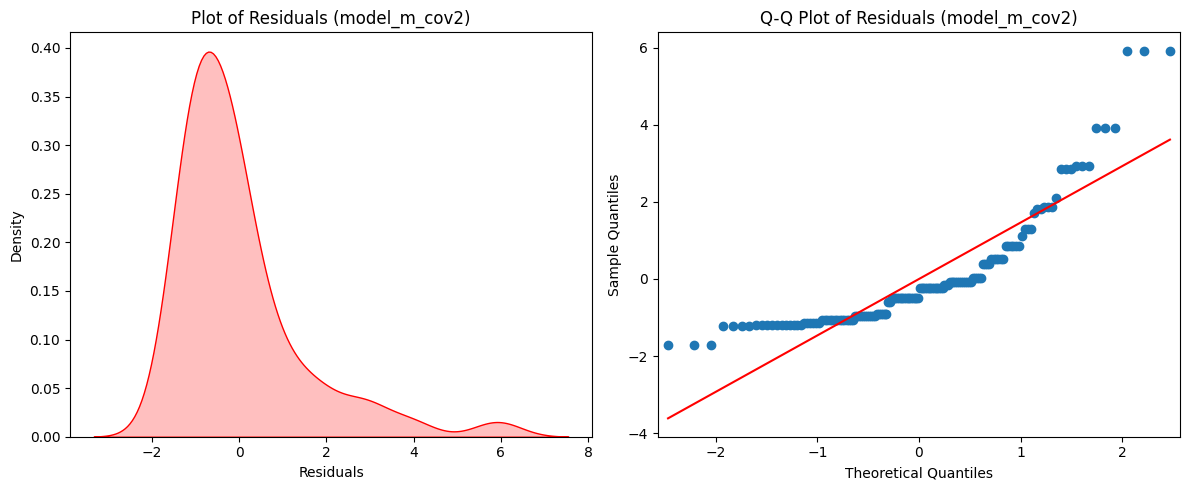

In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get residuals from the fitted model
residual_m_co2 = model_m_cov2.resid

# Visualization: KDE plot and Q-Q plot for residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot for residuals with fill
sns.kdeplot(residual_m_co2, ax=ax[0], color='red', fill=True)
ax[0].set_title('Plot of Residuals (model_m_cov2)')
ax[0].set_xlabel('Residuals')

# Q-Q plot to assess normality
sm.qqplot(residual_m_co2, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot of Residuals (model_m_cov2)')

# Final layout
plt.tight_layout()
plt.show()


In [ ]:
from scipy import stats

# Perform Shapiro-Wilk test on residuals from model_m_cov2
shapiro_resid = stats.shapiro(residual_m_co2.dropna())

# Print the results
print("Shapiro-Wilk Test for Normality of Residuals (model_m_cov2):")
print(f'W-statistic: {round(shapiro_resid.statistic, 3)}, P-value: {round(shapiro_resid.pvalue, 3)}')


Shapiro-Wilk Test for Normality of Residuals (model_m_cov2):
W-statistic: 0.779, P-value: 0.0


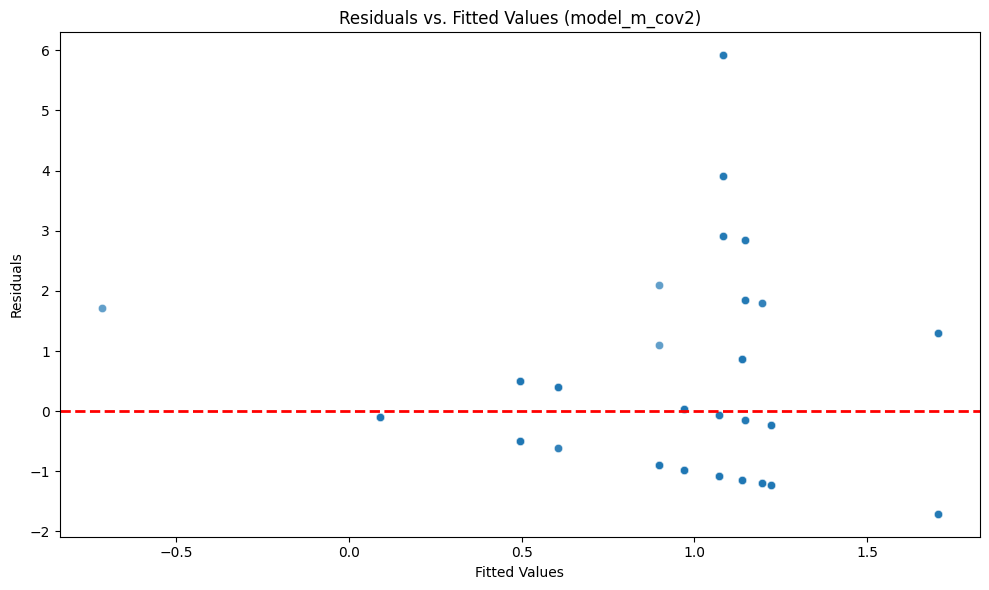

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Get residuals and fitted values from model_m_cov2
residual_m_co2 = model_m_cov2.resid
fitted_m_co2 = model_m_cov2.fittedvalues

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_m_co2, y=residual_m_co2, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Labels and title
plt.title("Residuals vs. Fitted Values (model_m_cov2)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()
